# Plot BT Task Maps (Per Tree)

This notebook:
- Loads task outputs from one model run folder
- Re-simulates each parsed behavior tree with `record_path=True`
- Plots one map per task with different colors per tree path
- Skips trees that do not parse
- Skips tasks where no trees parse

In [8]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Ensure repo root is importable when notebook cwd is elsewhere
start = Path.cwd()
repo_root = None
for p in [start, *start.parents]:
    if (p / "src").exists() and (p / "results").exists():
        repo_root = p
        break
if repo_root is None:
    raise FileNotFoundError("Could not locate repo root containing src/ and results/")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.parsers.bt import parse_bt_output
from src.simulator import simulate_bt_plan

In [9]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "tasks" / "tasks_100.json").exists() and (p / "results").exists():
            return p
    raise FileNotFoundError("Could not find repo root.")

repo_root = find_repo_root(Path.cwd())
results_root = repo_root / "results"

# Target model folder relative to results/
model_rel = Path("wall_bt_2026-04-29_15-21-54/Qwen/Qwen2.5-3B-Instruct")
model_dir = model_rel if model_rel.is_absolute() else (results_root / model_rel)
tasks_dir = model_dir / "tasks"

if not tasks_dir.exists():
    raise FileNotFoundError(f"Missing tasks dir: {tasks_dir}")

tasks_catalog_path = repo_root / "src" / "tasks" / "tasks_100.json"
tasks_catalog = json.loads(tasks_catalog_path.read_text(encoding="utf-8"))
task_by_id = {t["task_id"]: t for t in tasks_catalog}

task_files = sorted(tasks_dir.glob("task_*.json"))
print(f"Model dir: {model_dir}")
print(f"Found {len(task_files)} task files")

Model dir: c:\Users\Owner\OneDrive\Documents\Work\Robotics Research\LLM_Structure_Adherence\results\wall_bt_2026-04-29_15-21-54\Qwen\Qwen2.5-3B-Instruct
Found 100 task files


In [10]:
def draw_rect(ax, rect, edgecolor, facecolor, alpha=0.2, lw=1.5):
    x1, y1, x2, y2 = rect["x1"], rect["y1"], rect["x2"], rect["y2"]
    patch = Rectangle(
        (min(x1, x2), min(y1, y2)),
        abs(x2 - x1),
        abs(y2 - y1),
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        lw=lw,
    )
    ax.add_patch(patch)


def plot_maps_for_task_type(task_type: str, start_version: int = 1, end_version: int = 20):
    plotted = 0
    skipped_no_parsed = 0

    for version in range(start_version, end_version + 1):
        task_id = f"{task_type}_v{version}"
        task_file = tasks_dir / f"task_{task_id}.json"
        if not task_file.exists():
            continue

        task_data = json.loads(task_file.read_text(encoding="utf-8"))
        task_meta = task_by_id.get(task_id)
        if task_meta is None:
            print(f"Skipping {task_file.name}: task_id not found in tasks_100.json")
            continue

        world = task_meta["world"]
        task_env = {**world, "task_type": task_type}

        behavior_trees = task_data.get("behavior_trees", [])
        current_spot = None
        tree_paths = []

        # Re-run each parsed tree to recover the path.
        for i, bt in enumerate(behavior_trees, start=1):
            raw_output = bt.get("llm_output", "")
            plan, err = parse_bt_output(raw_output)
            if err is not None:
                continue

            result = simulate_bt_plan(
                plan,
                spot_state=current_spot,
                task_env=task_env,
                record_path=True,
            )
            path = result.get("path", [])
            if path:
                tree_paths.append((i, path))
            current_spot = result.get("final_spot", current_spot)

        if not tree_paths:
            skipped_no_parsed += 1
            continue

        # Searchable task marker in output
        print(f"\n=== task_id: {task_id} ===")

        fig, ax = plt.subplots(figsize=(7, 6))

        for obs in world.get("obstacles", []):
            draw_rect(ax, obs, edgecolor="black", facecolor="gray", alpha=0.35)

        for tgt in world.get("targets", []):
            draw_rect(ax, tgt, edgecolor="green", facecolor="lime", alpha=0.25)

        cmap = plt.cm.get_cmap("tab10", max(1, len(tree_paths)))
        for color_idx, (tree_idx, path) in enumerate(tree_paths):
            xs = [p["x"] for p in path]
            ys = [p["y"] for p in path]
            ax.plot(xs, ys, color=cmap(color_idx), linewidth=2, label=f"tree_{tree_idx}")
            ax.scatter([xs[0]], [ys[0]], color=cmap(color_idx), s=20)
            ax.scatter([xs[-1]], [ys[-1]], color=cmap(color_idx), s=40, marker="x")

        ax.scatter([0.0], [0.0], color="blue", marker="*", s=130, label="start")
        ax.set_title(f"{task_id} ({task_type})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.axis("equal")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=8)
        plt.show()

        plotted += 1

    print(f"\n{task_type}: plotted={plotted}, skipped_no_parsed={skipped_no_parsed}")

## go_to_target (v1-v20)


=== task_id: go_to_target_v1 ===


C:\Users\Owner\AppData\Local\Temp\ipykernel_11528\3751268565.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(tree_paths)))


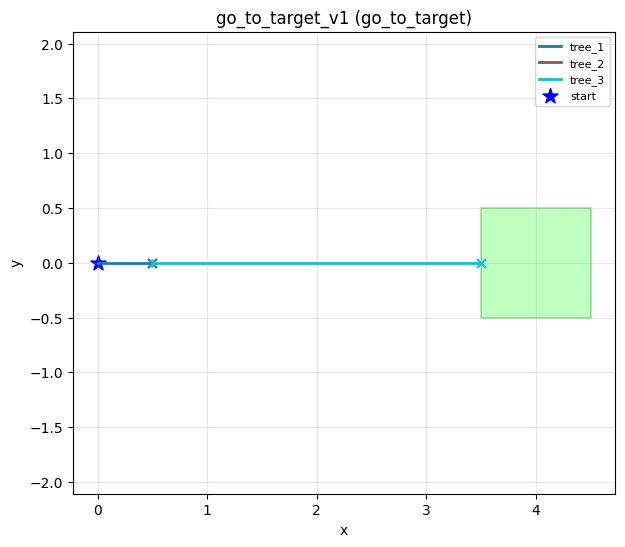


=== task_id: go_to_target_v2 ===


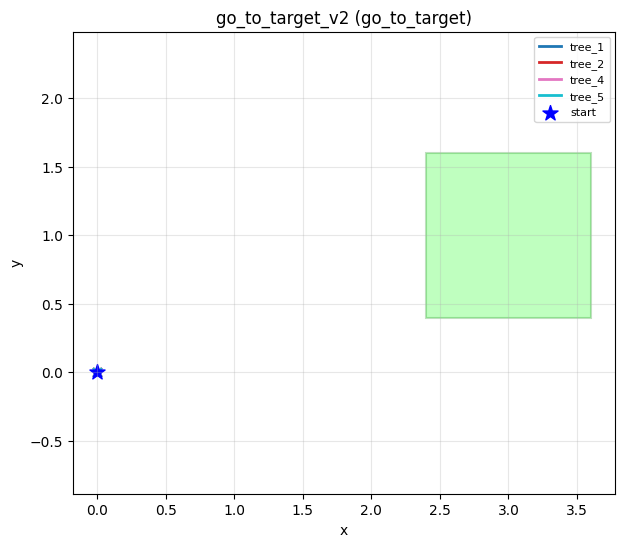


=== task_id: go_to_target_v3 ===


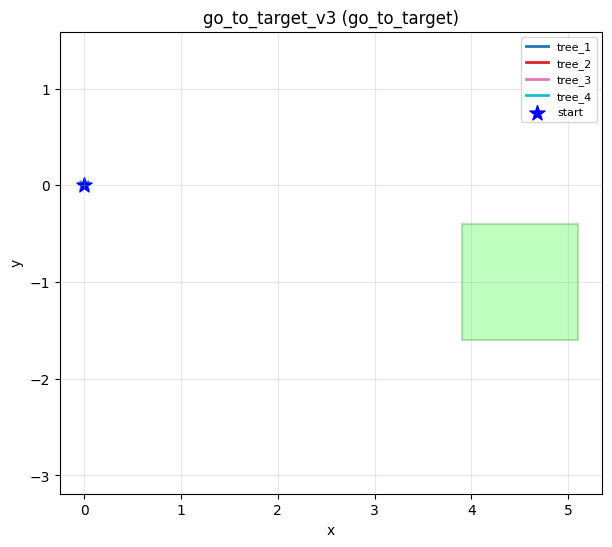


=== task_id: go_to_target_v4 ===


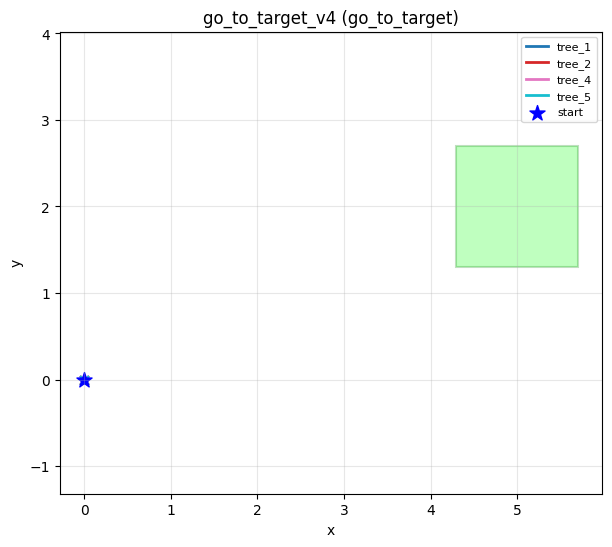


=== task_id: go_to_target_v5 ===


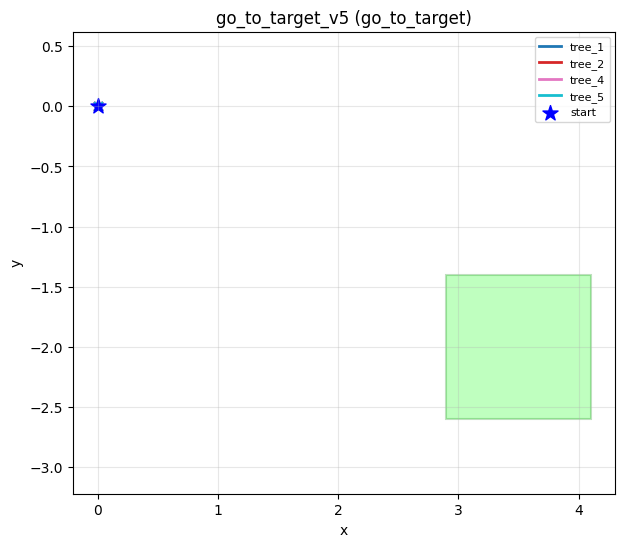


=== task_id: go_to_target_v6 ===


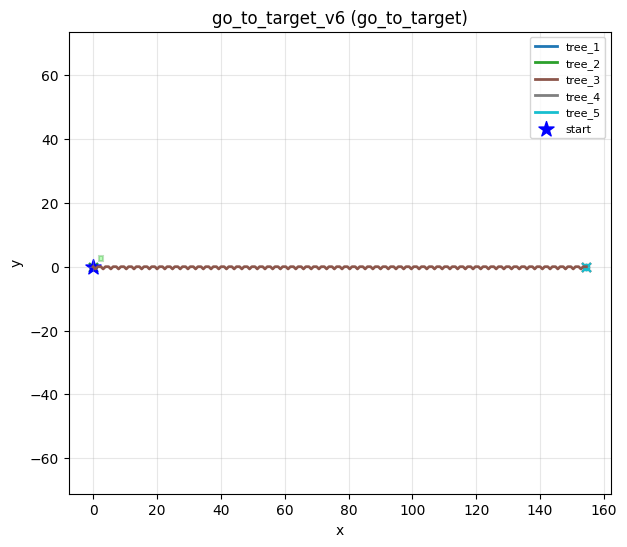


=== task_id: go_to_target_v7 ===


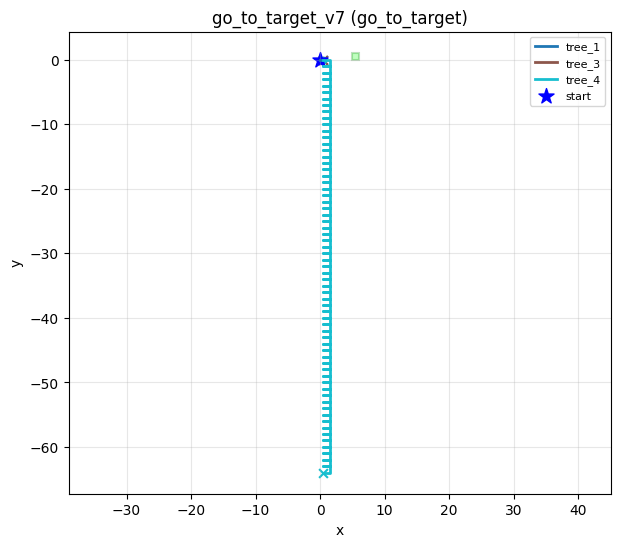


=== task_id: go_to_target_v8 ===


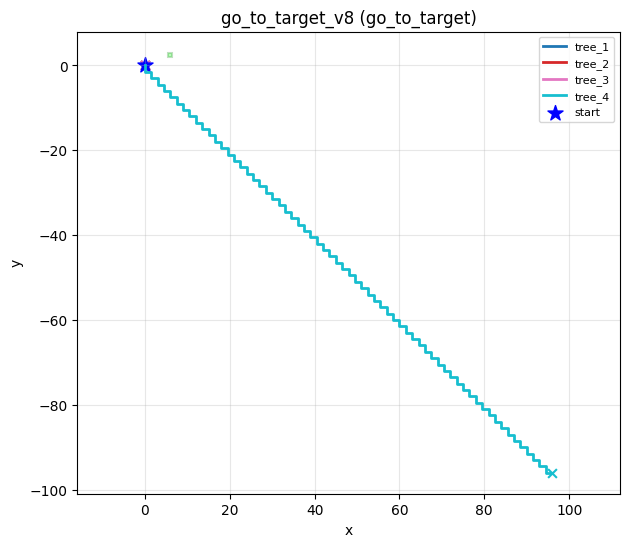


=== task_id: go_to_target_v9 ===


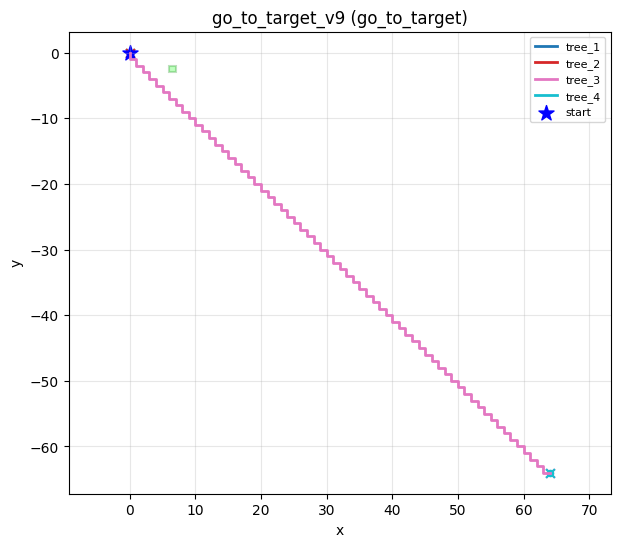


=== task_id: go_to_target_v10 ===


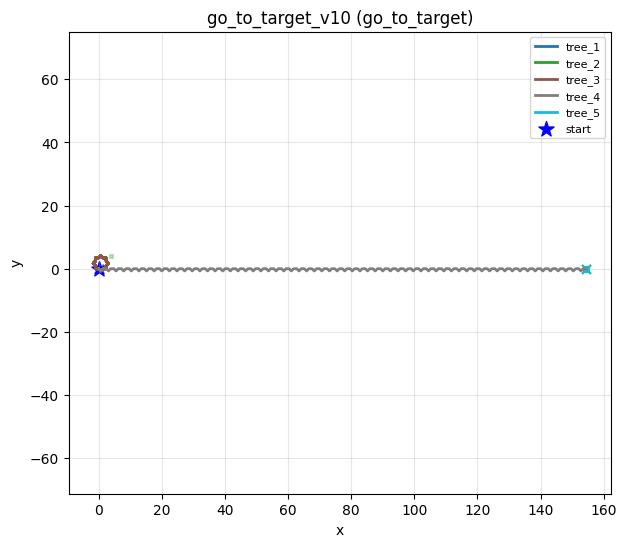


=== task_id: go_to_target_v11 ===


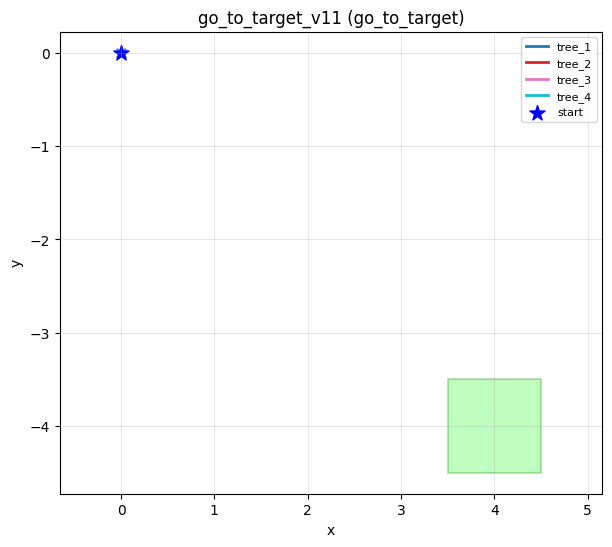


=== task_id: go_to_target_v12 ===


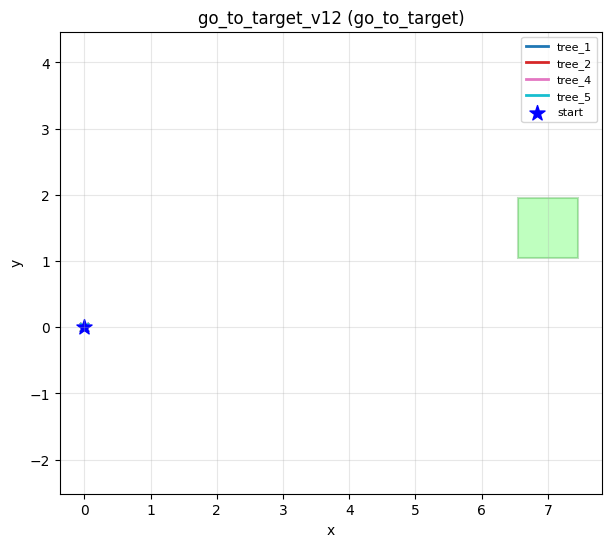


=== task_id: go_to_target_v13 ===


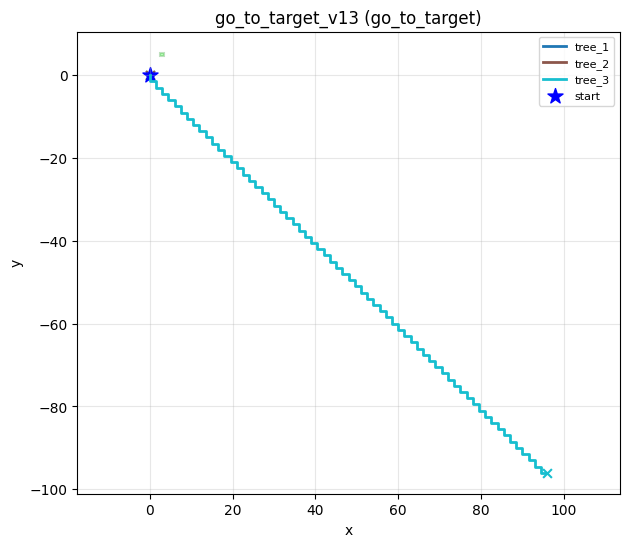


=== task_id: go_to_target_v14 ===


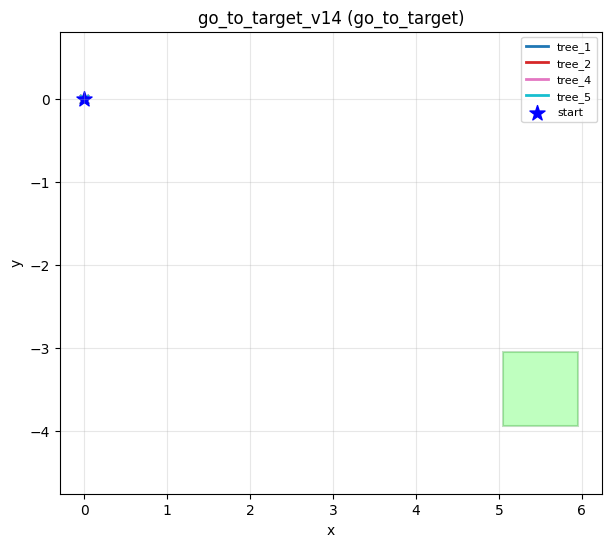


=== task_id: go_to_target_v15 ===


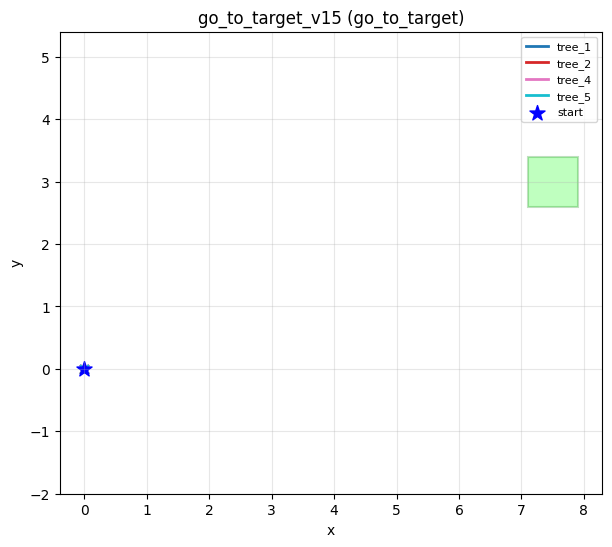


=== task_id: go_to_target_v16 ===


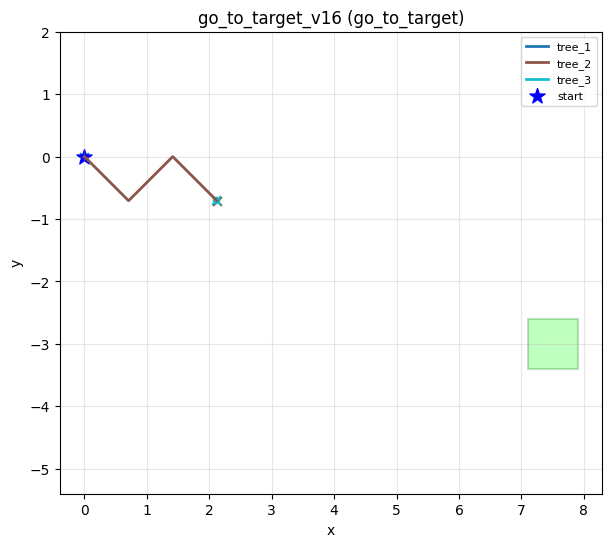


=== task_id: go_to_target_v17 ===


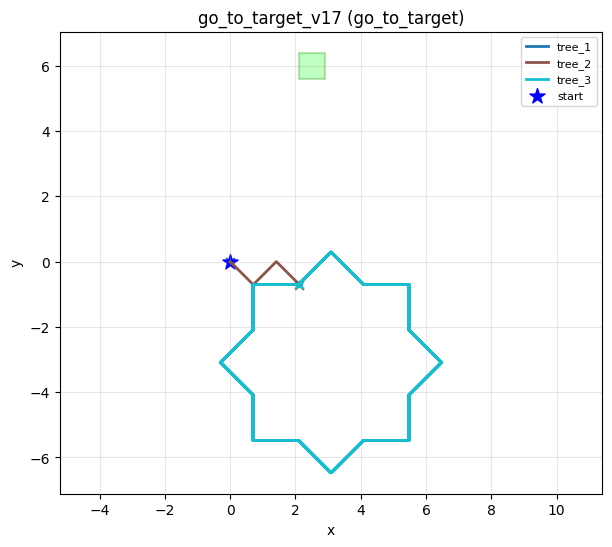


=== task_id: go_to_target_v18 ===


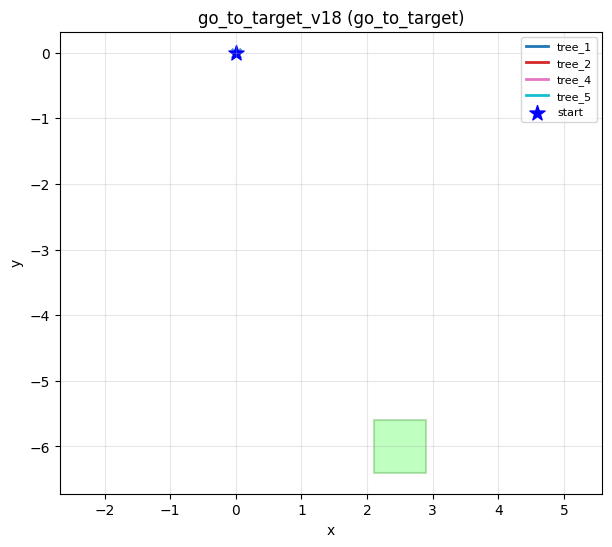


=== task_id: go_to_target_v19 ===


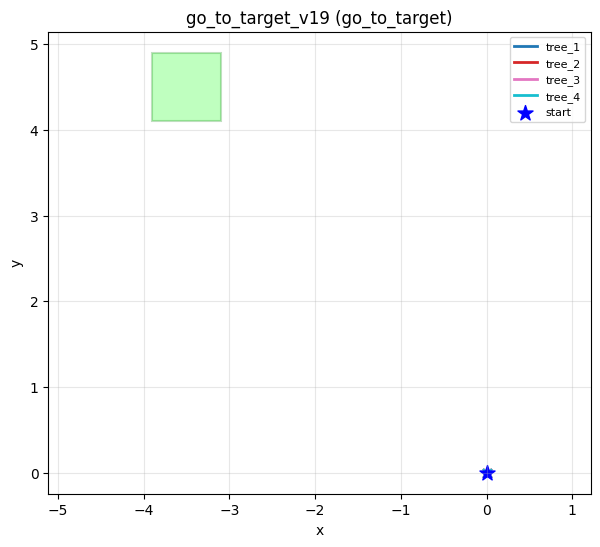


=== task_id: go_to_target_v20 ===


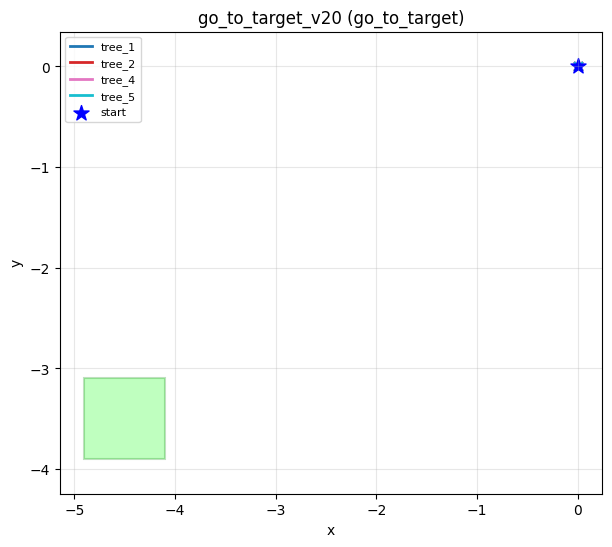


go_to_target: plotted=20, skipped_no_parsed=0


In [11]:
plot_maps_for_task_type("go_to_target", 1, 20)

## face_target (v1-v20)


=== task_id: face_target_v1 ===


C:\Users\Owner\AppData\Local\Temp\ipykernel_11528\3751268565.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(tree_paths)))


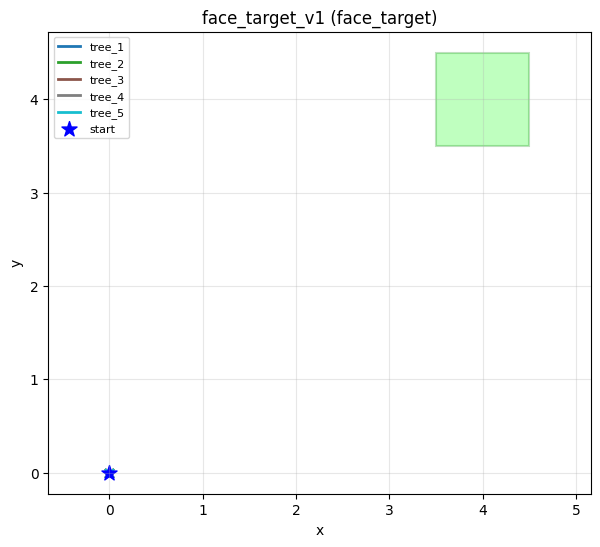


=== task_id: face_target_v2 ===


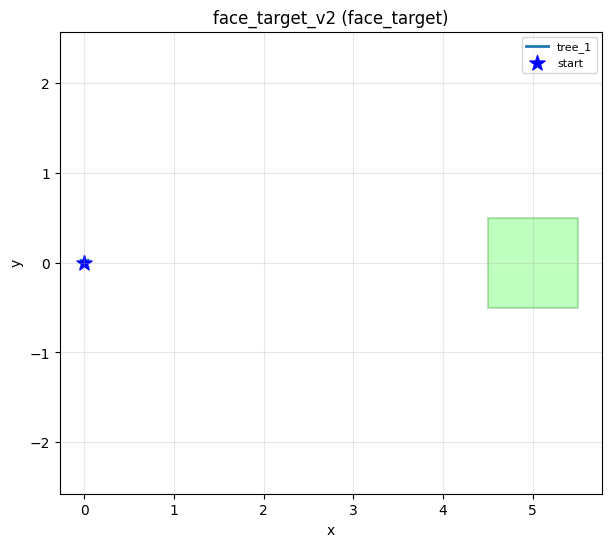


=== task_id: face_target_v3 ===


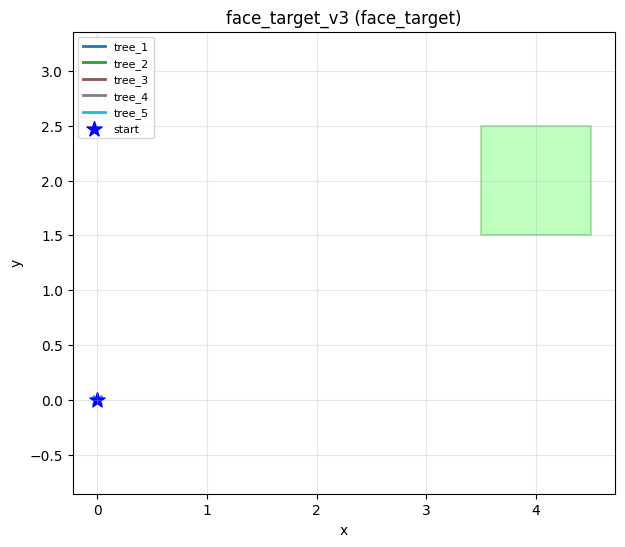


=== task_id: face_target_v4 ===


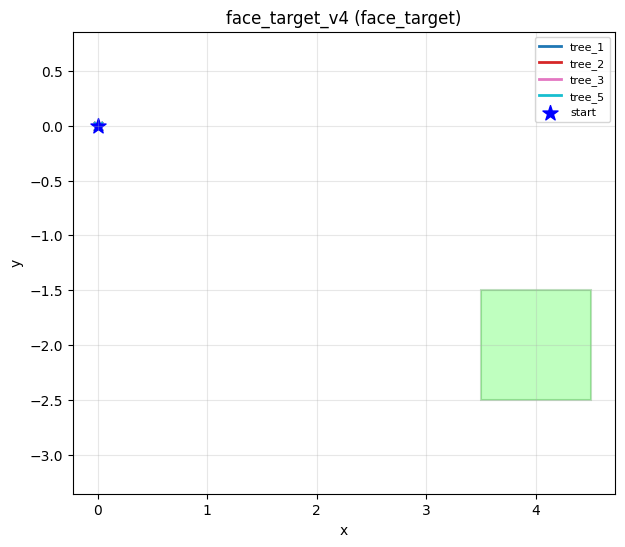


=== task_id: face_target_v5 ===


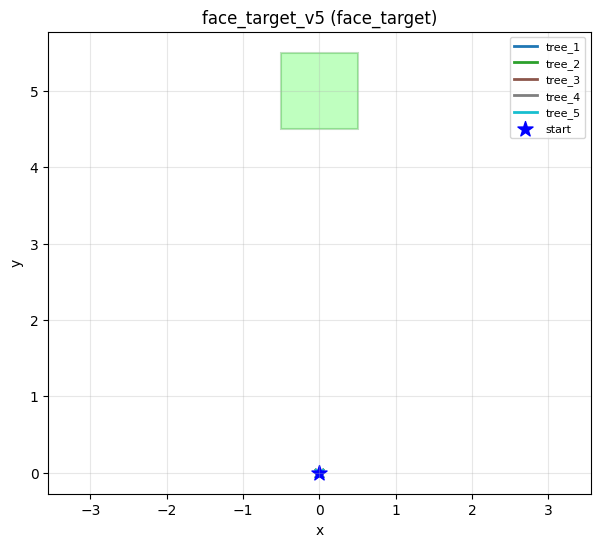


=== task_id: face_target_v6 ===


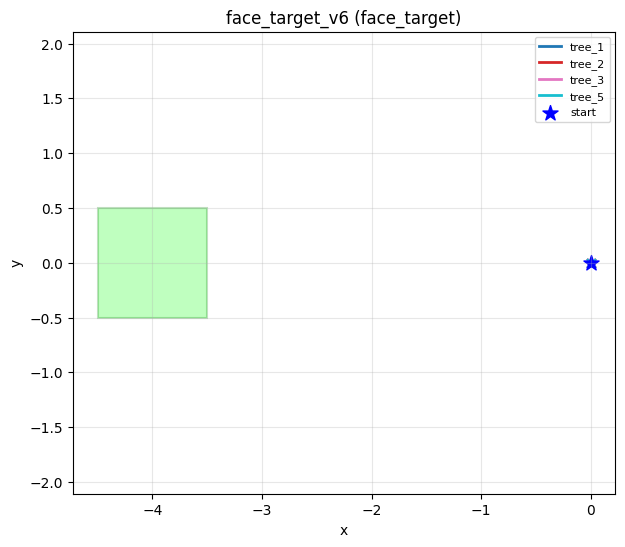


=== task_id: face_target_v7 ===


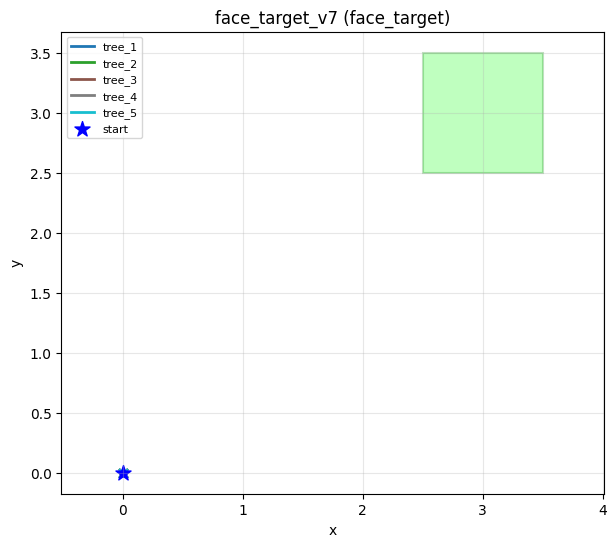


=== task_id: face_target_v8 ===


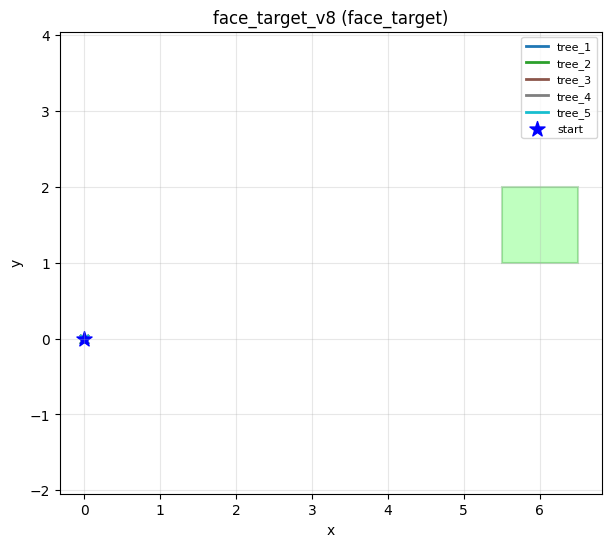


=== task_id: face_target_v9 ===


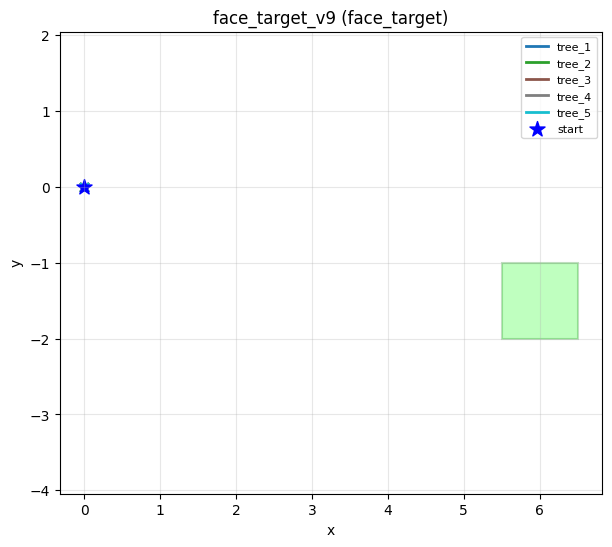


=== task_id: face_target_v10 ===


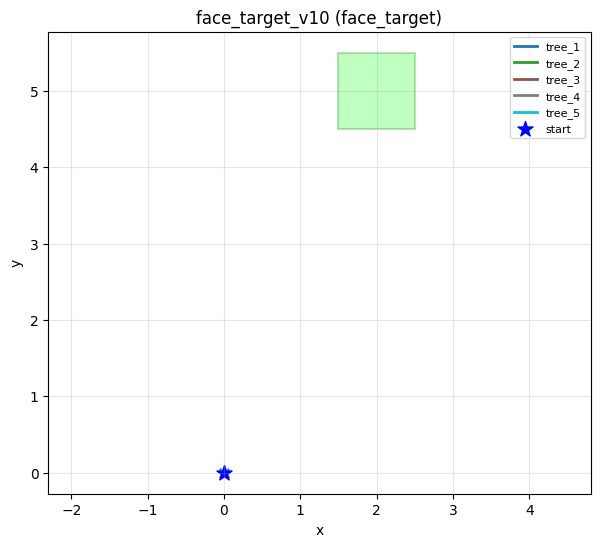


=== task_id: face_target_v11 ===


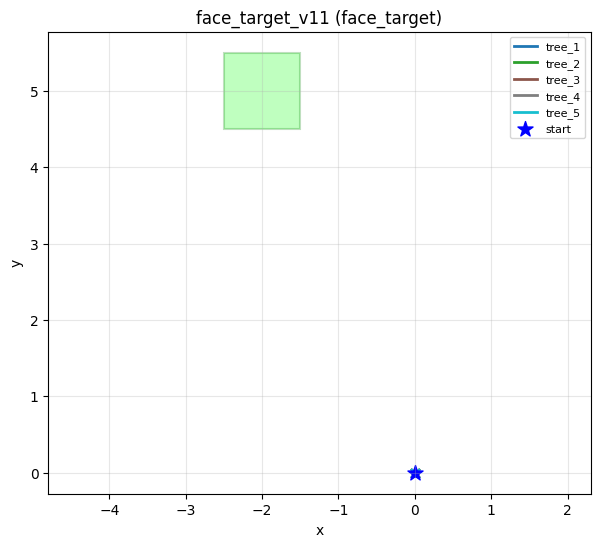


=== task_id: face_target_v12 ===


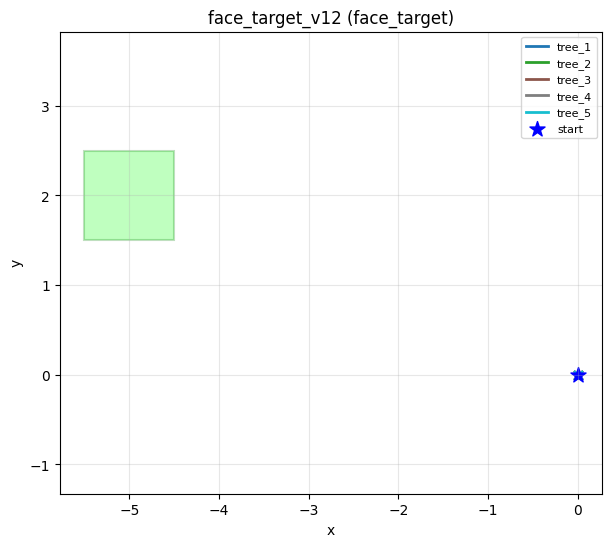


=== task_id: face_target_v13 ===


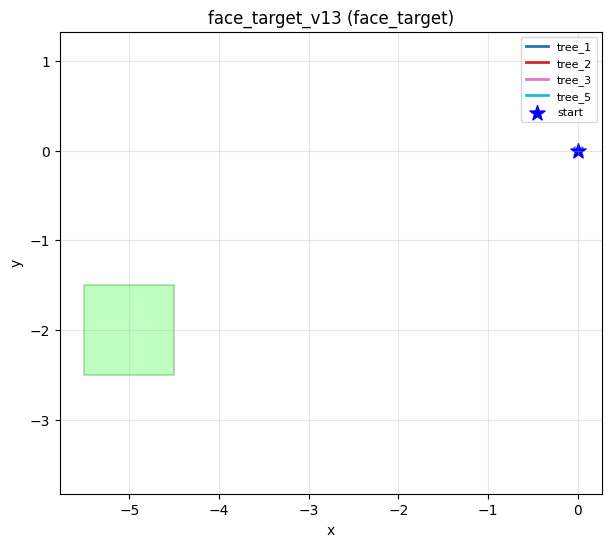


=== task_id: face_target_v14 ===


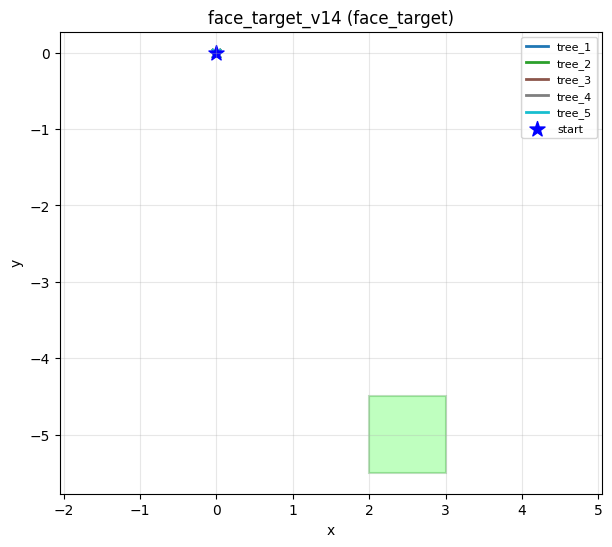


=== task_id: face_target_v15 ===


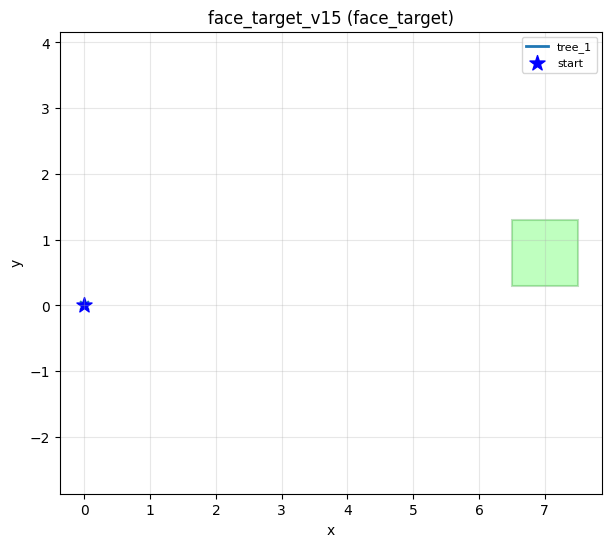


=== task_id: face_target_v16 ===


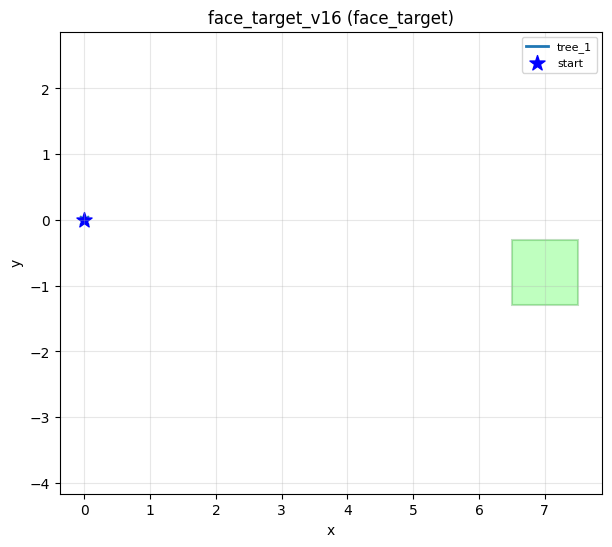


=== task_id: face_target_v17 ===


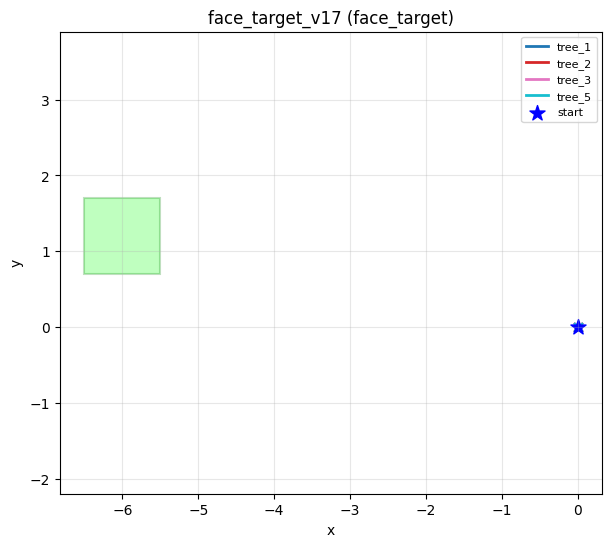


=== task_id: face_target_v18 ===


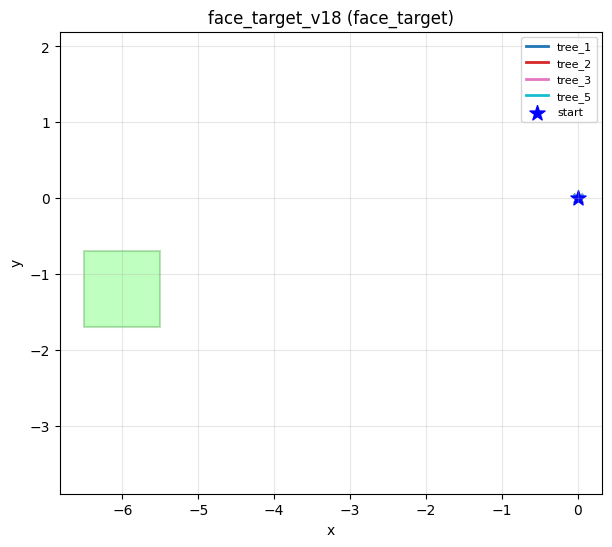


=== task_id: face_target_v19 ===


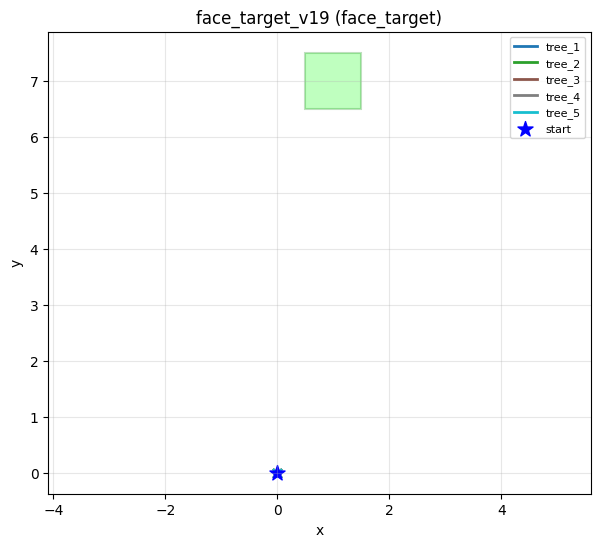


=== task_id: face_target_v20 ===


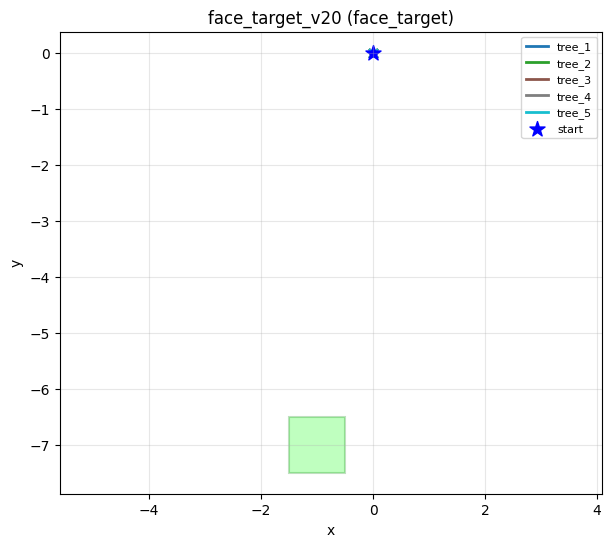


face_target: plotted=20, skipped_no_parsed=0


In [12]:
plot_maps_for_task_type("face_target", 1, 20)

## move_to_closest_target (v1-v20)


=== task_id: move_to_closest_target_v1 ===


C:\Users\Owner\AppData\Local\Temp\ipykernel_11528\3751268565.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(tree_paths)))


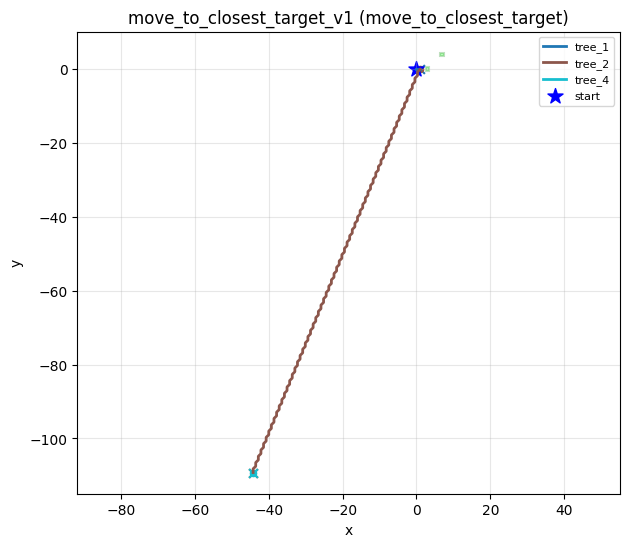


=== task_id: move_to_closest_target_v2 ===


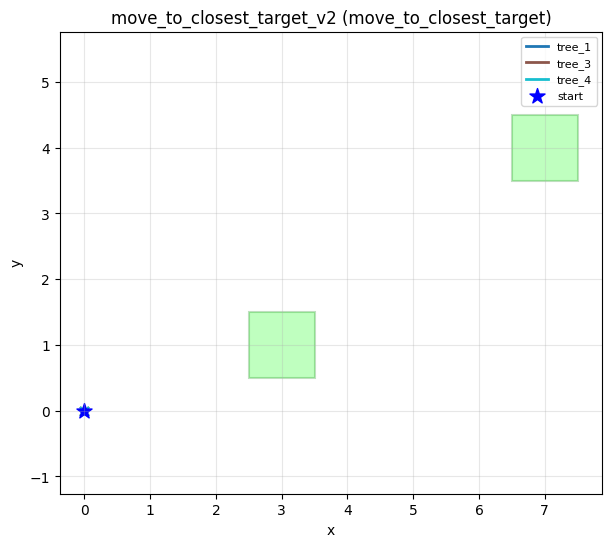


=== task_id: move_to_closest_target_v3 ===


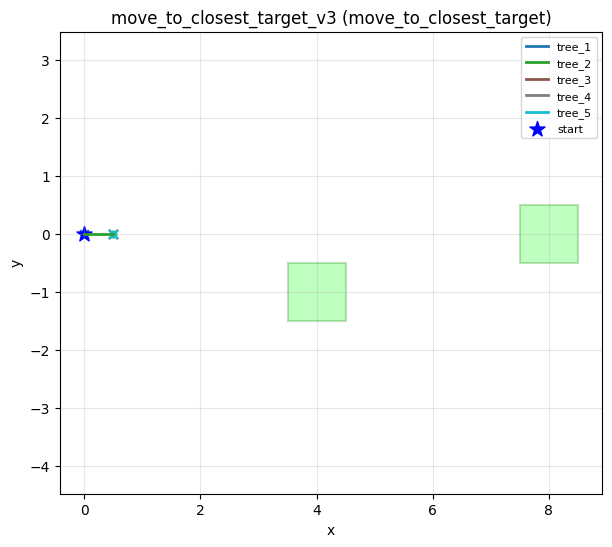


=== task_id: move_to_closest_target_v4 ===


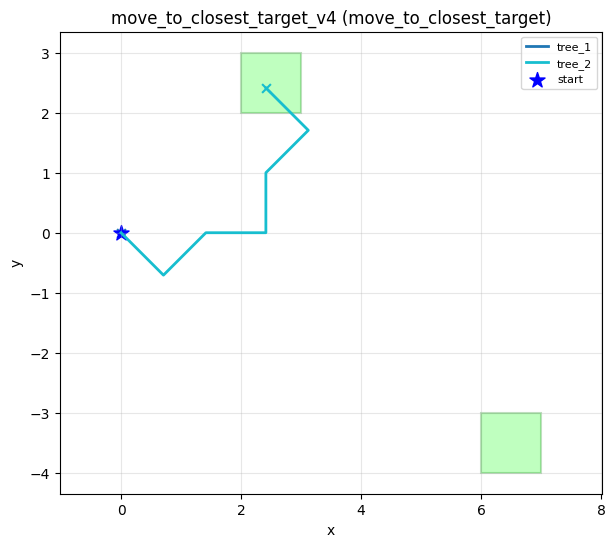


=== task_id: move_to_closest_target_v5 ===


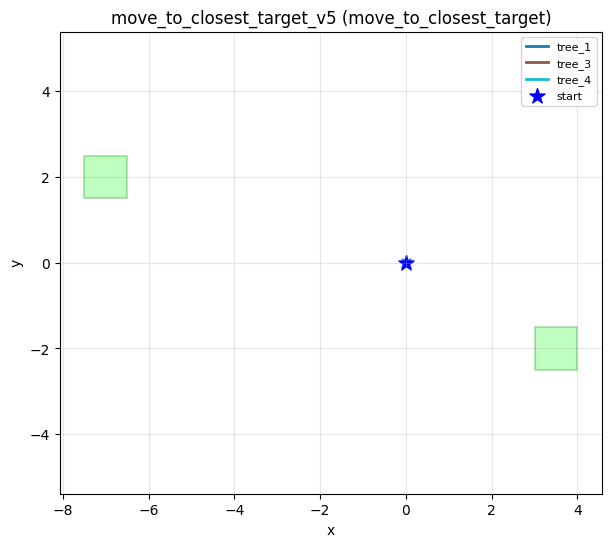


=== task_id: move_to_closest_target_v6 ===


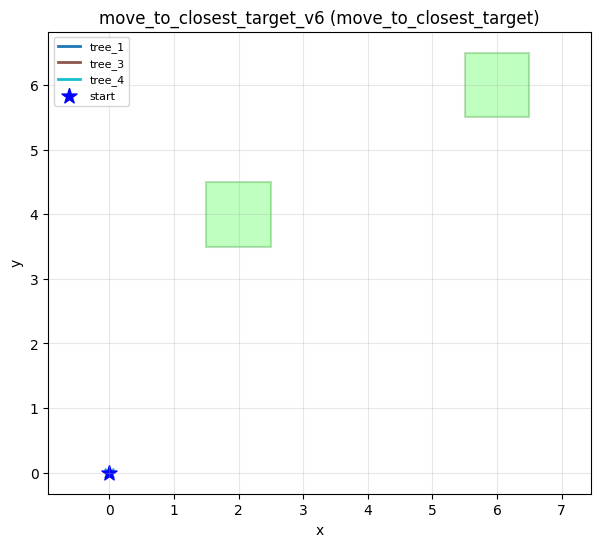


=== task_id: move_to_closest_target_v7 ===


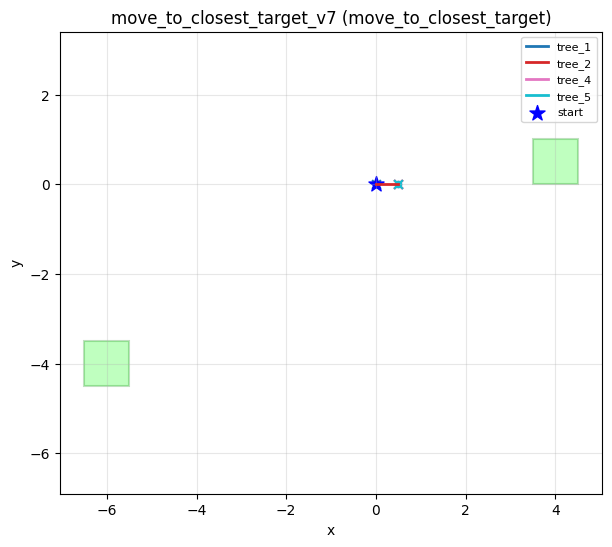


=== task_id: move_to_closest_target_v8 ===


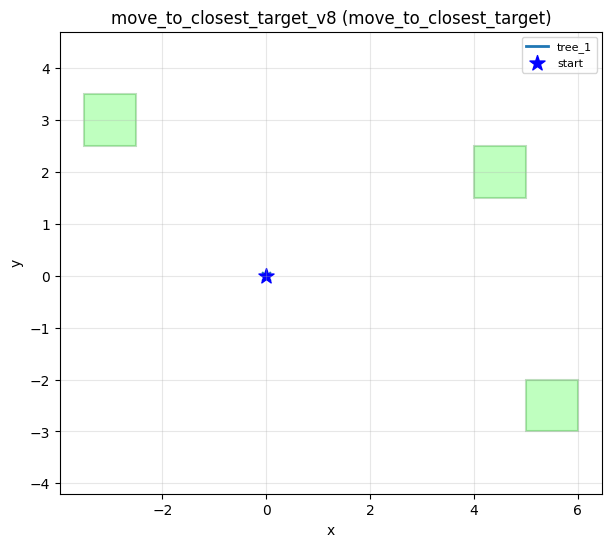


=== task_id: move_to_closest_target_v9 ===


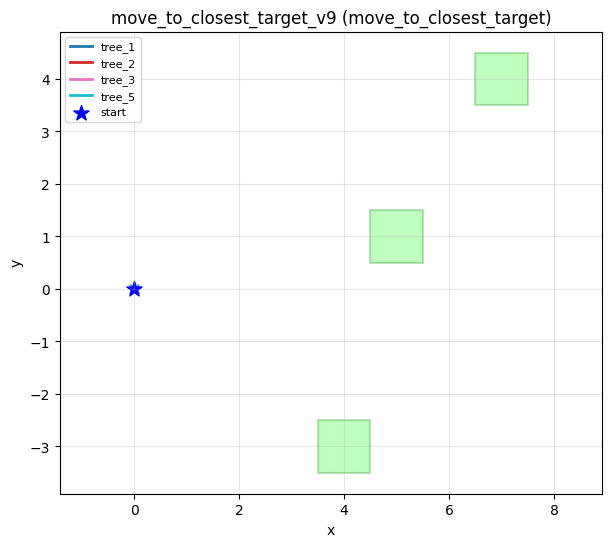


=== task_id: move_to_closest_target_v10 ===


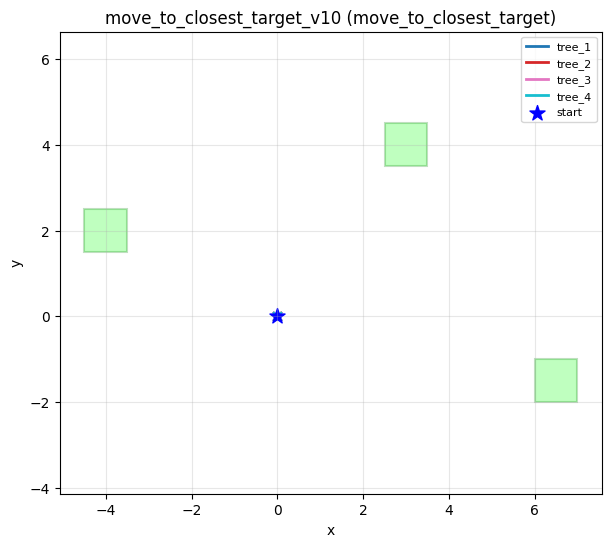


=== task_id: move_to_closest_target_v11 ===


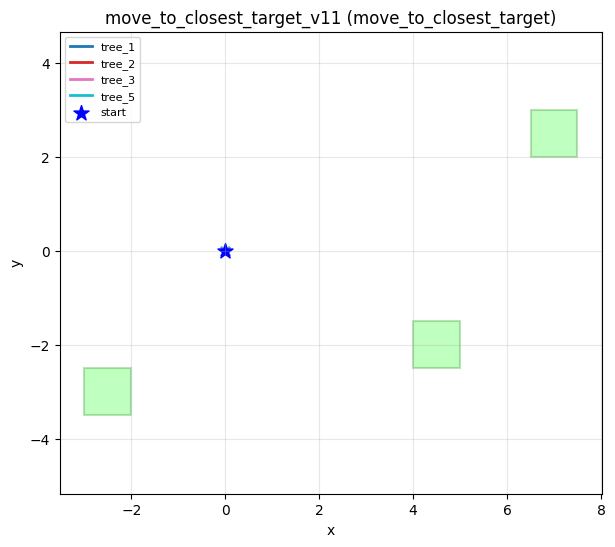


=== task_id: move_to_closest_target_v12 ===


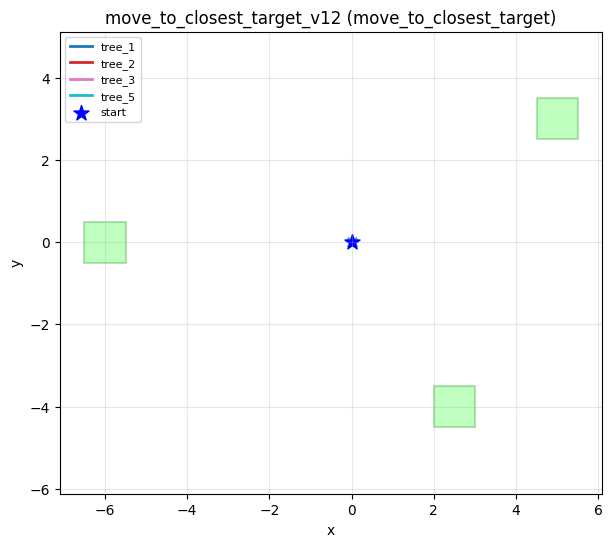


=== task_id: move_to_closest_target_v13 ===


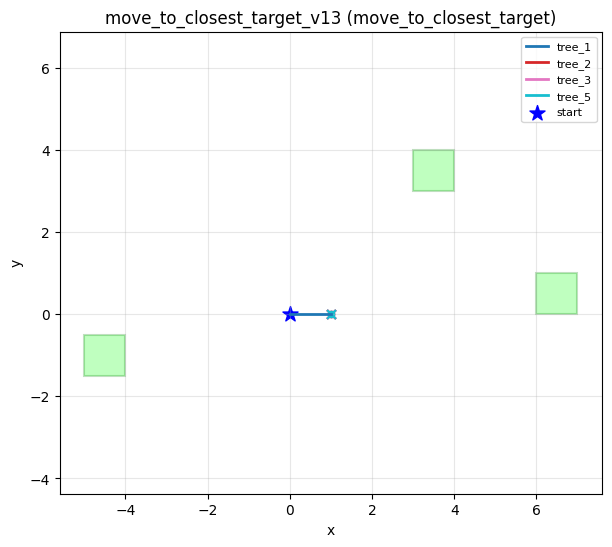


=== task_id: move_to_closest_target_v14 ===


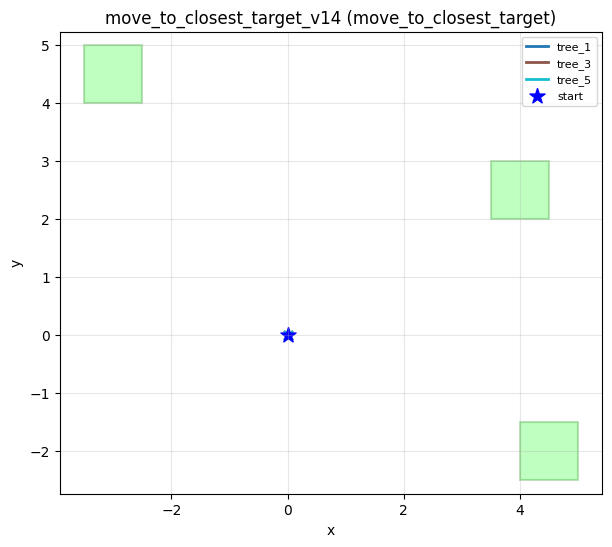


=== task_id: move_to_closest_target_v15 ===


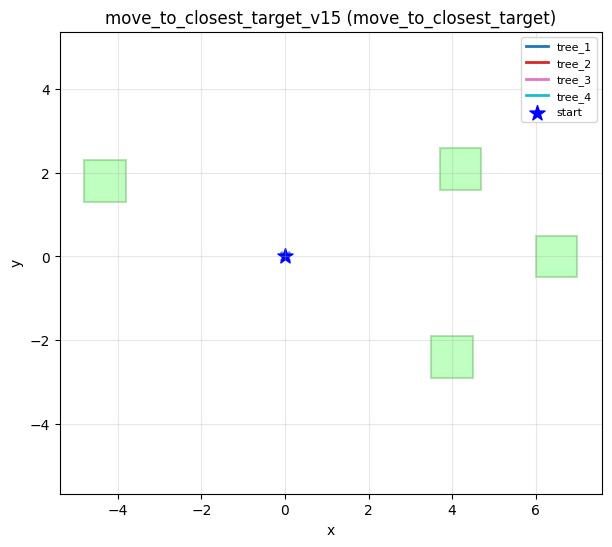


=== task_id: move_to_closest_target_v16 ===


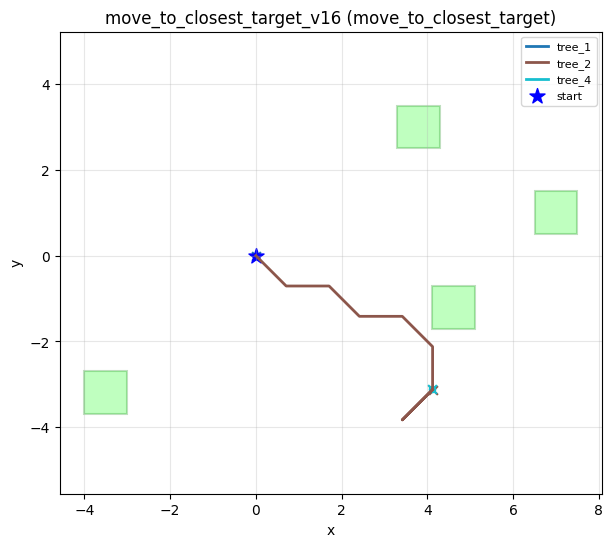


=== task_id: move_to_closest_target_v17 ===


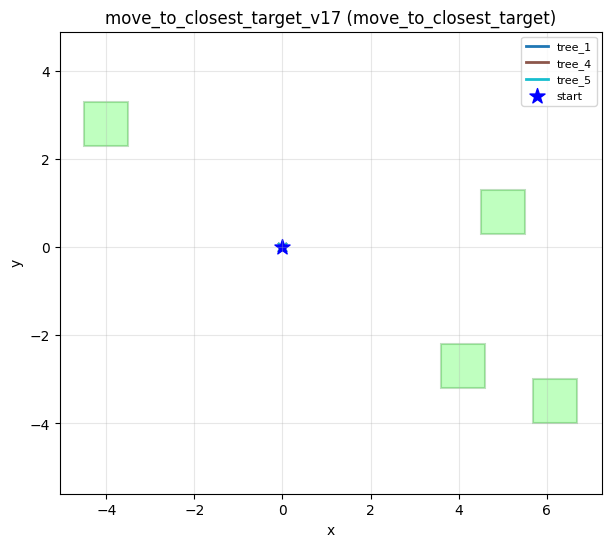


=== task_id: move_to_closest_target_v18 ===


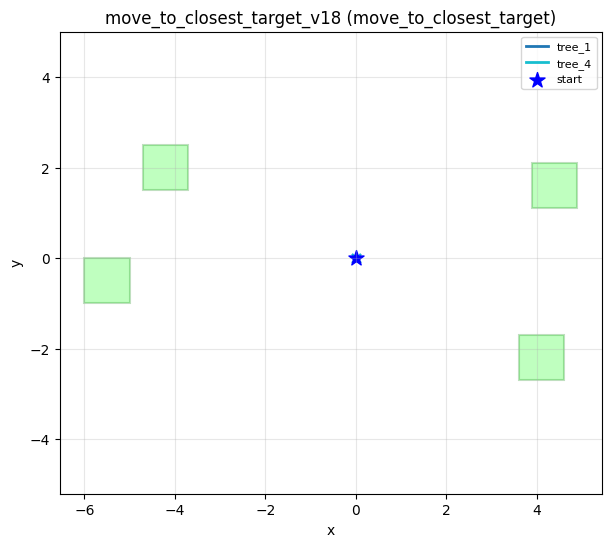


=== task_id: move_to_closest_target_v19 ===


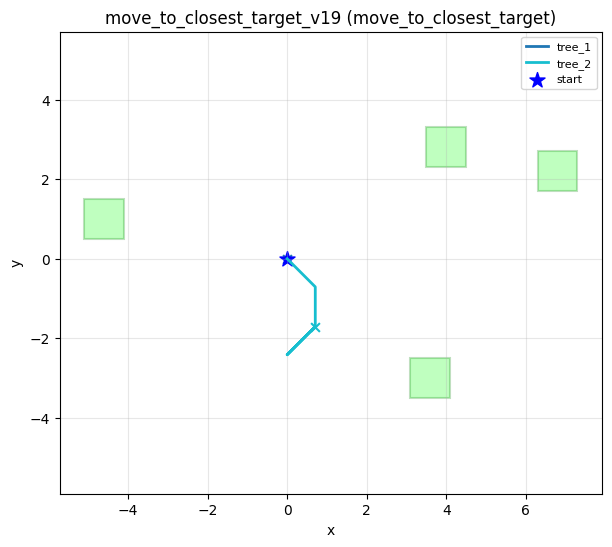


=== task_id: move_to_closest_target_v20 ===


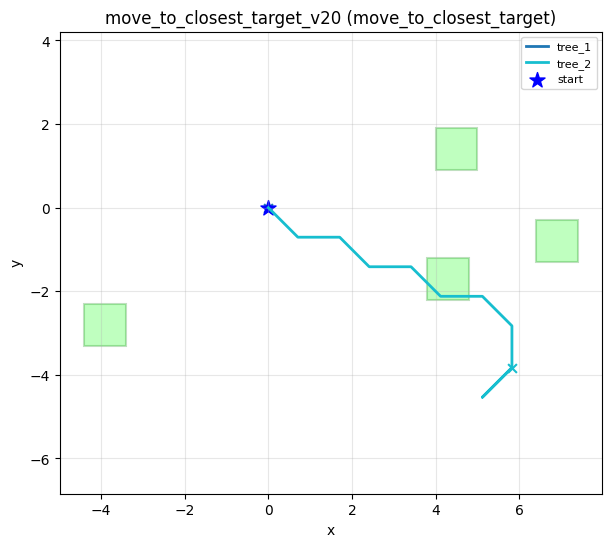


move_to_closest_target: plotted=20, skipped_no_parsed=0


In [13]:
plot_maps_for_task_type("move_to_closest_target", 1, 20)

## go_to_multiple_targets (v1-v20)


=== task_id: go_to_multiple_targets_v1 ===


C:\Users\Owner\AppData\Local\Temp\ipykernel_11528\3751268565.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(tree_paths)))


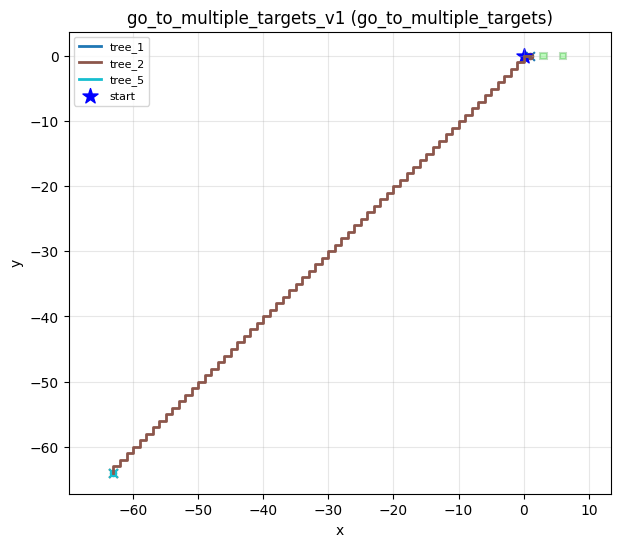


=== task_id: go_to_multiple_targets_v2 ===


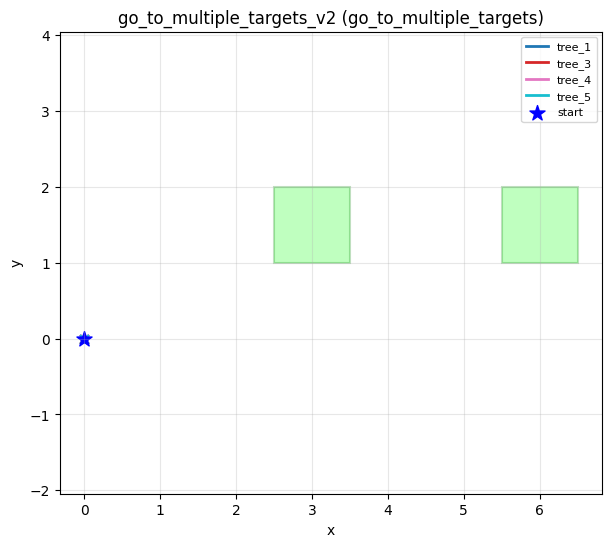


=== task_id: go_to_multiple_targets_v3 ===


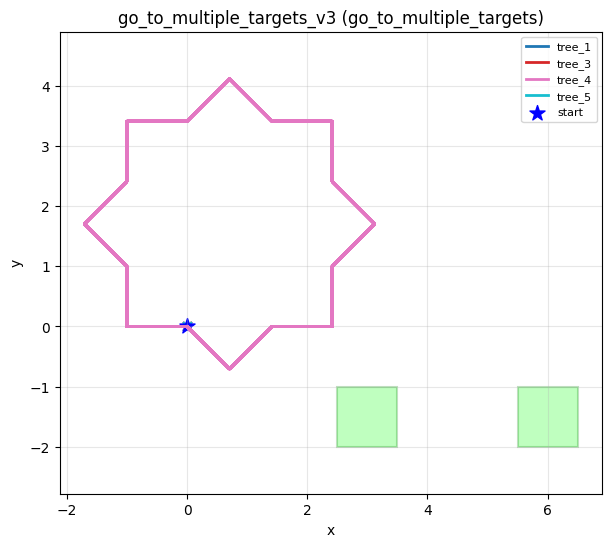


=== task_id: go_to_multiple_targets_v4 ===


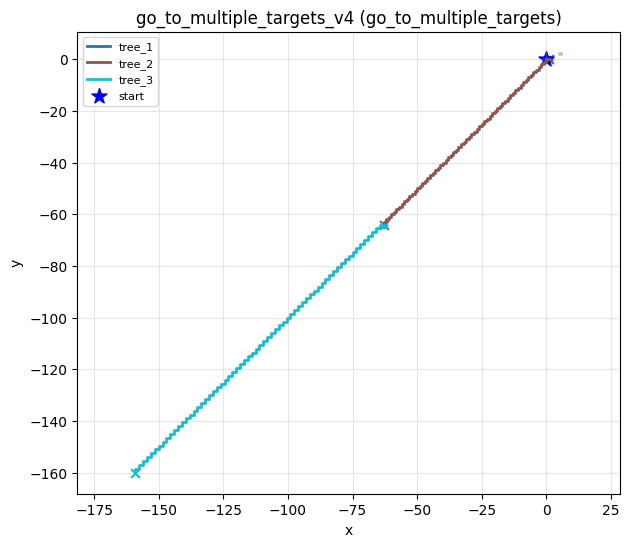


=== task_id: go_to_multiple_targets_v5 ===


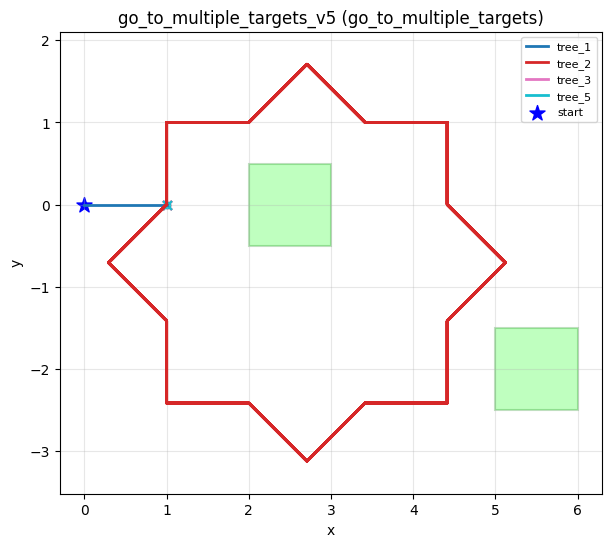


=== task_id: go_to_multiple_targets_v6 ===


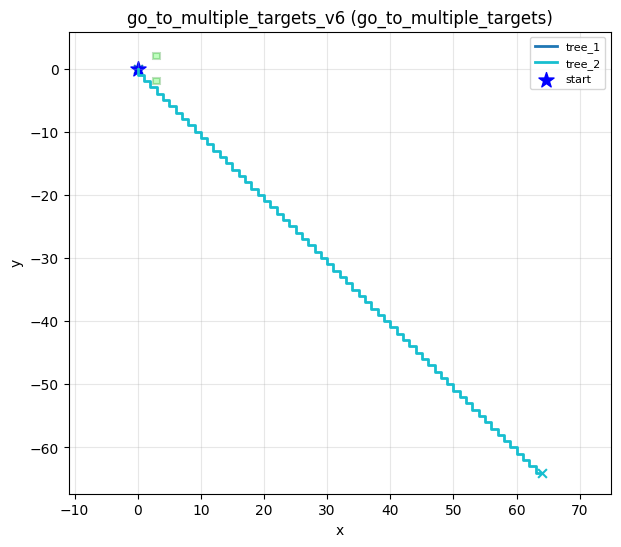


=== task_id: go_to_multiple_targets_v7 ===


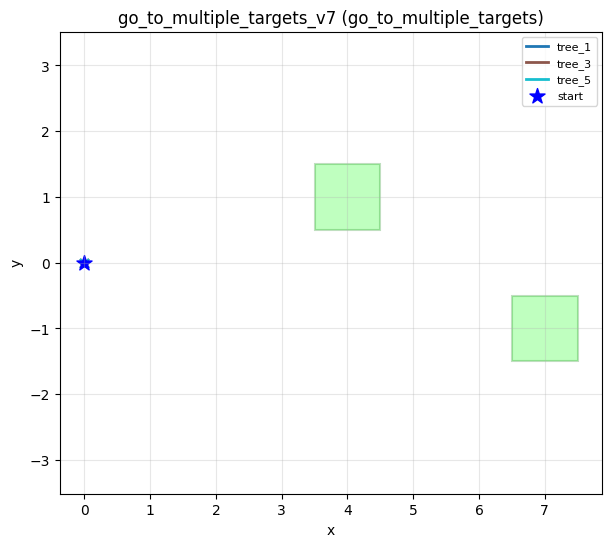


=== task_id: go_to_multiple_targets_v8 ===


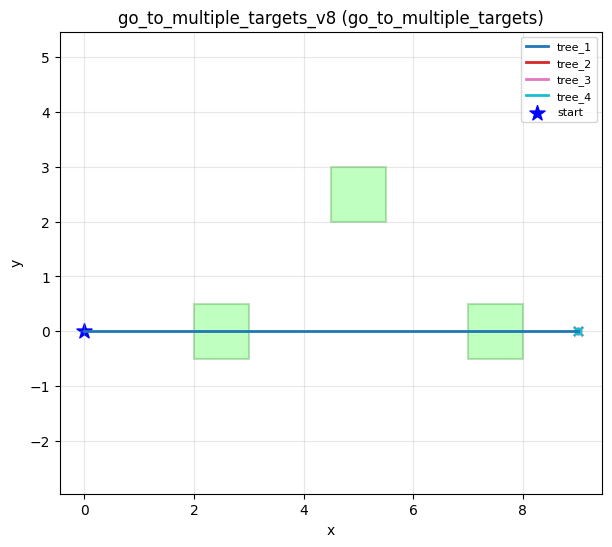


=== task_id: go_to_multiple_targets_v9 ===


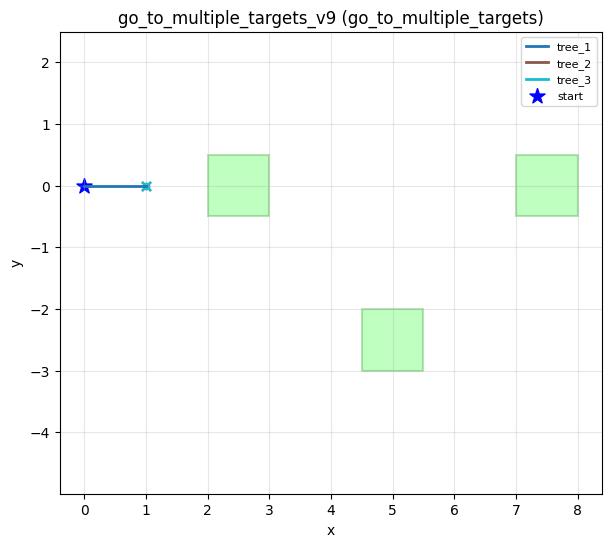


=== task_id: go_to_multiple_targets_v10 ===


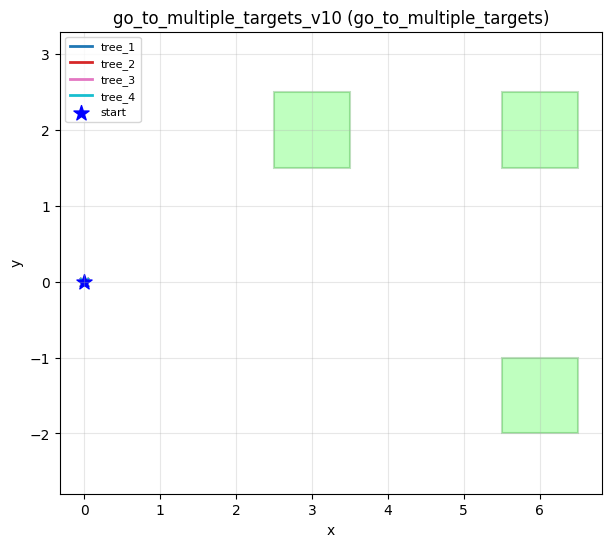


=== task_id: go_to_multiple_targets_v11 ===


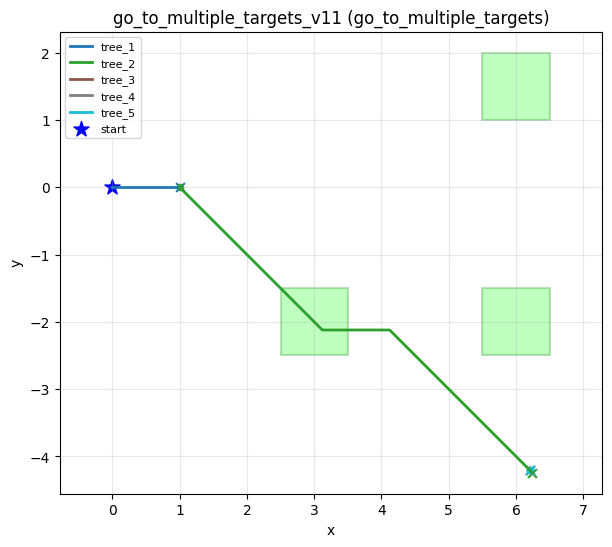


=== task_id: go_to_multiple_targets_v12 ===


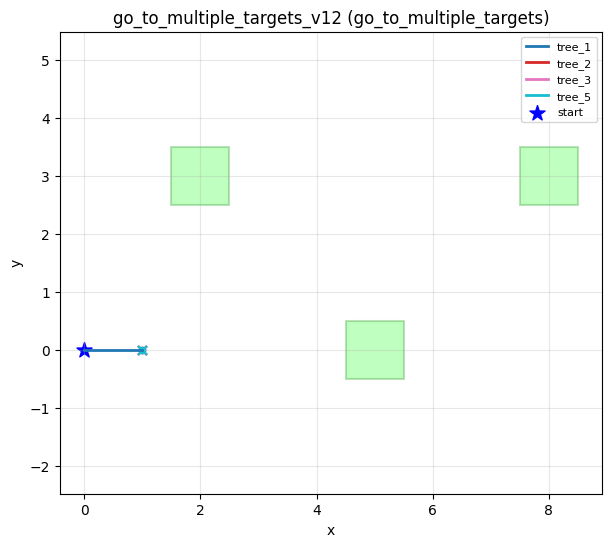


=== task_id: go_to_multiple_targets_v13 ===


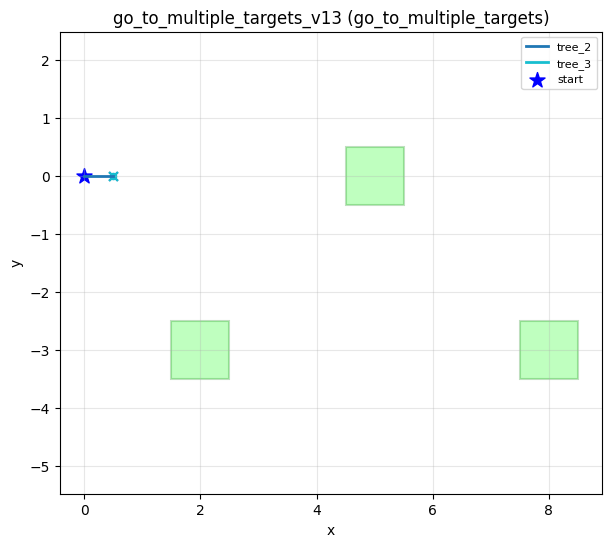


=== task_id: go_to_multiple_targets_v14 ===


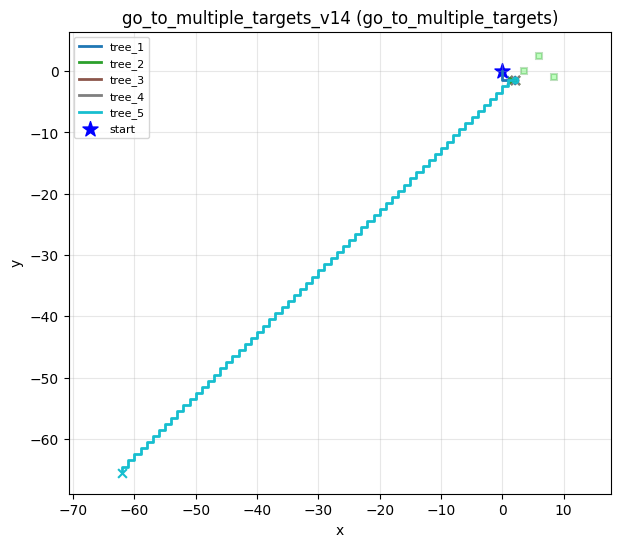


=== task_id: go_to_multiple_targets_v15 ===


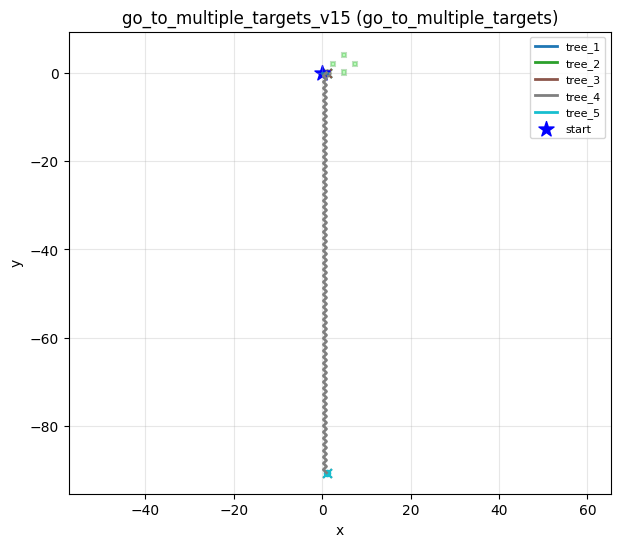


=== task_id: go_to_multiple_targets_v16 ===


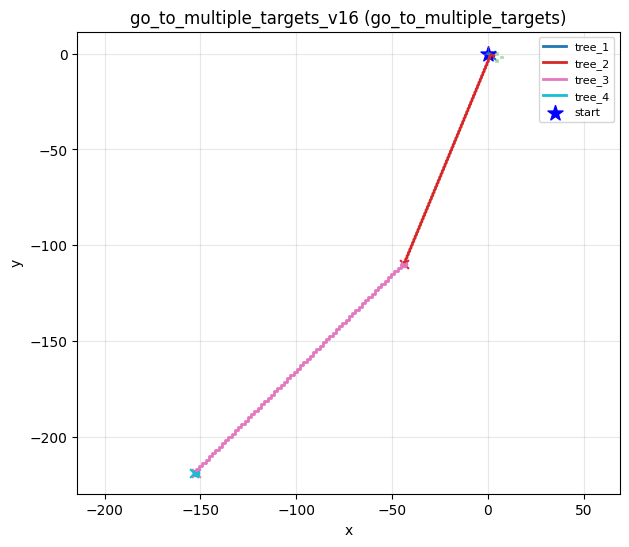


=== task_id: go_to_multiple_targets_v17 ===


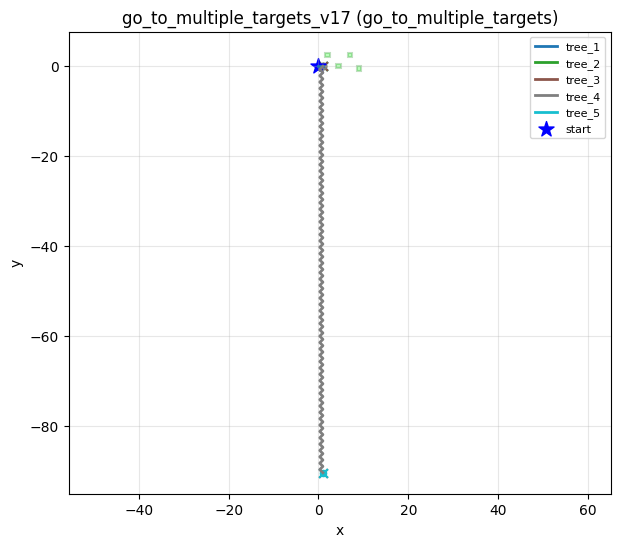


=== task_id: go_to_multiple_targets_v18 ===


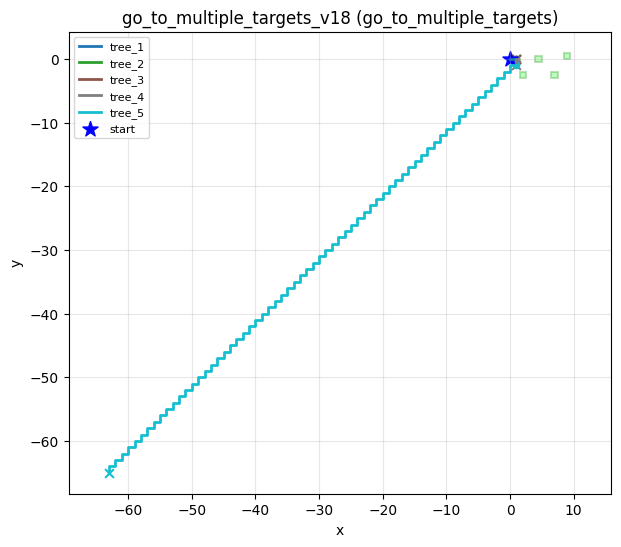


=== task_id: go_to_multiple_targets_v19 ===


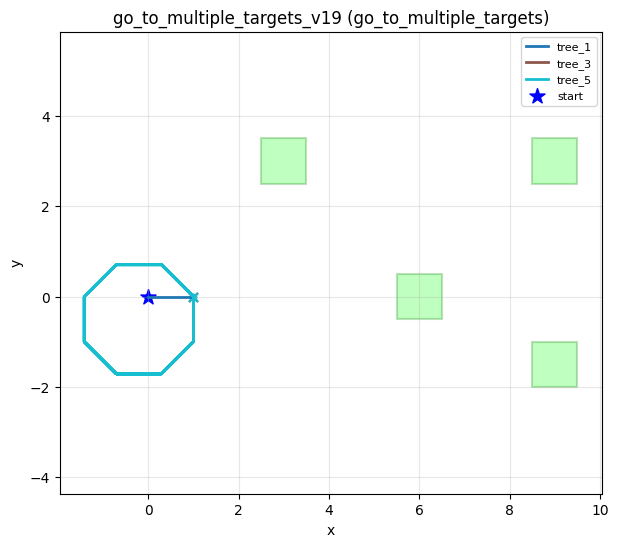


=== task_id: go_to_multiple_targets_v20 ===


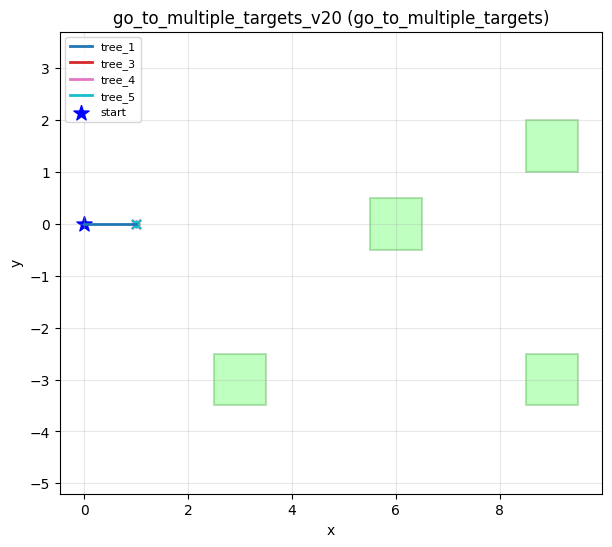


go_to_multiple_targets: plotted=20, skipped_no_parsed=0


In [14]:
plot_maps_for_task_type("go_to_multiple_targets", 1, 20)

## go_around_obstacle (v1-v20)


=== task_id: go_around_obstacle_v1 ===


C:\Users\Owner\AppData\Local\Temp\ipykernel_11528\3751268565.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", max(1, len(tree_paths)))


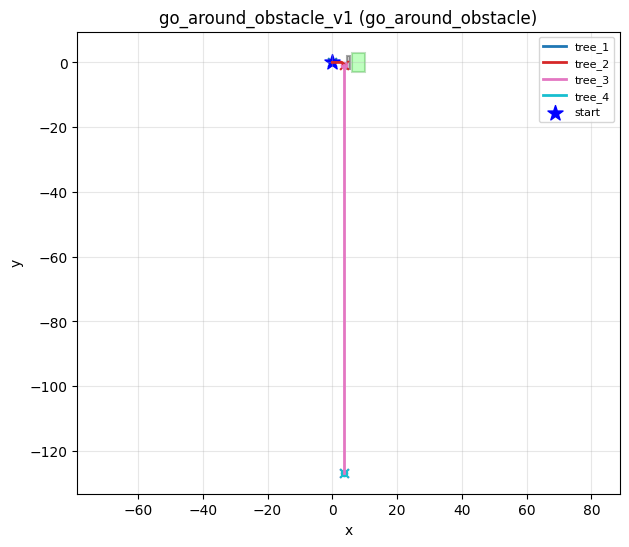


=== task_id: go_around_obstacle_v2 ===


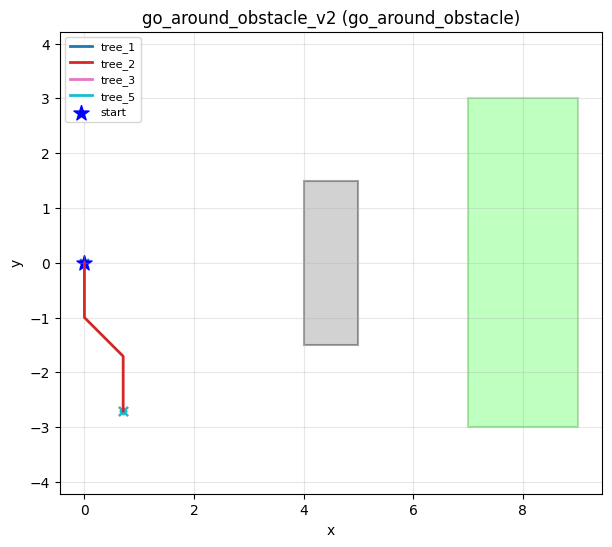


=== task_id: go_around_obstacle_v3 ===


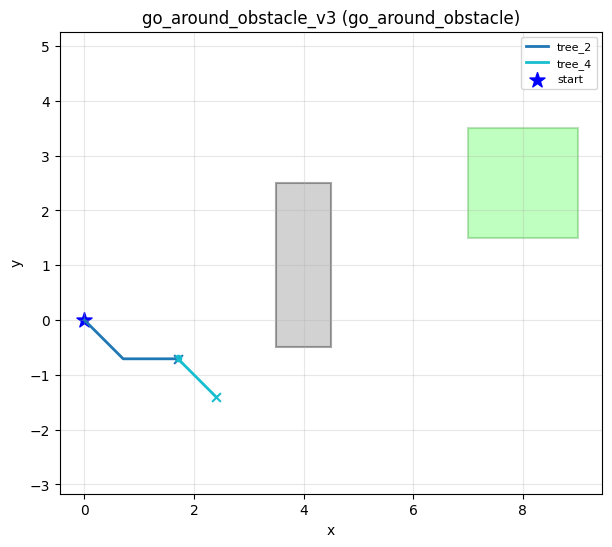


=== task_id: go_around_obstacle_v4 ===


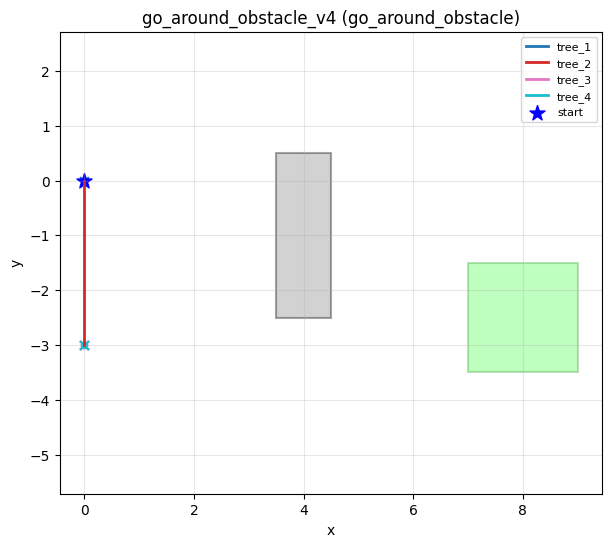


=== task_id: go_around_obstacle_v5 ===


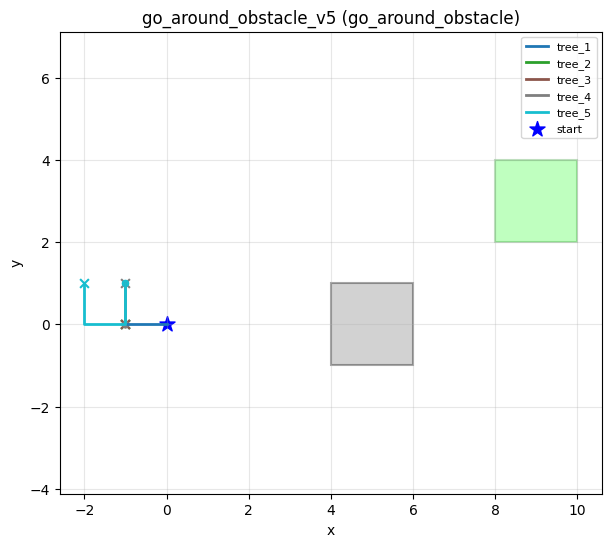


=== task_id: go_around_obstacle_v6 ===


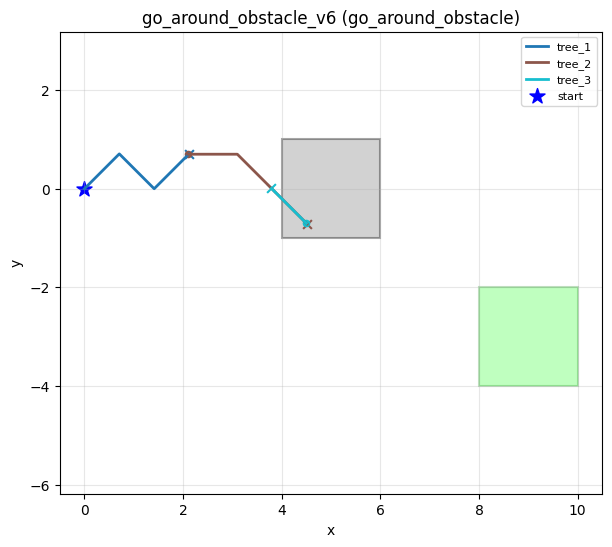


=== task_id: go_around_obstacle_v7 ===


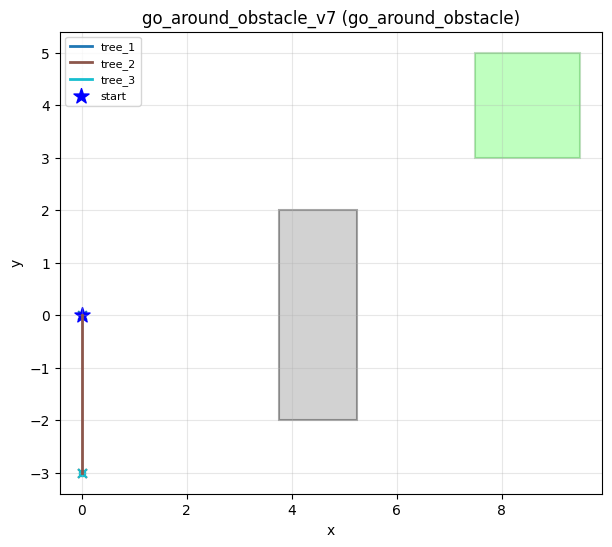


=== task_id: go_around_obstacle_v8 ===


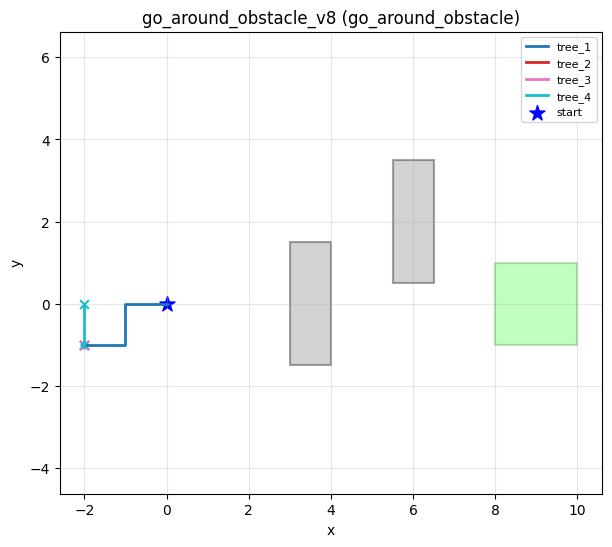


=== task_id: go_around_obstacle_v9 ===


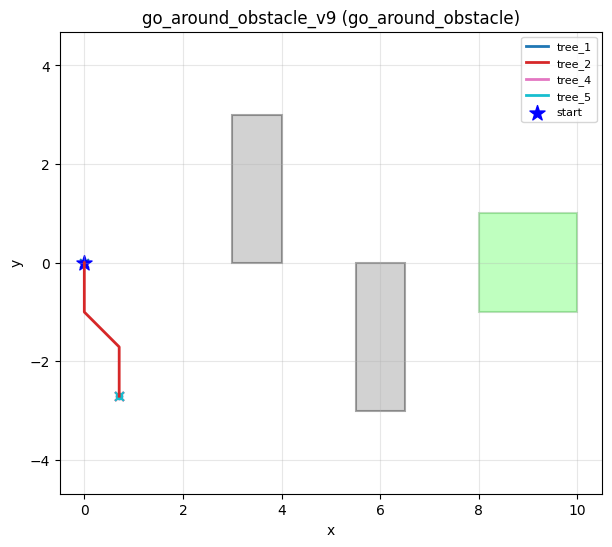


=== task_id: go_around_obstacle_v10 ===


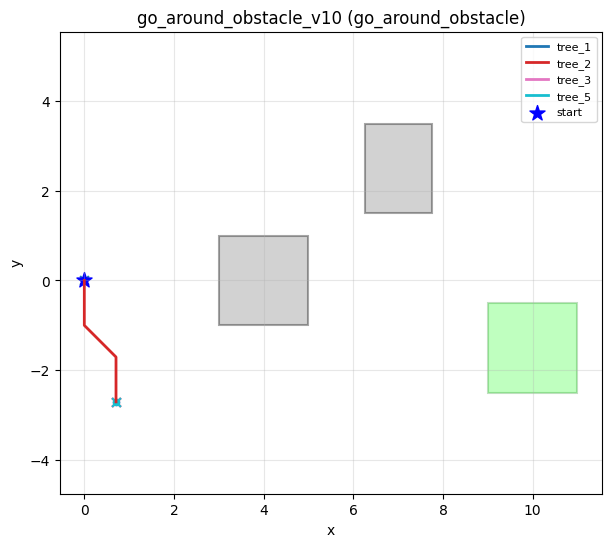


=== task_id: go_around_obstacle_v11 ===


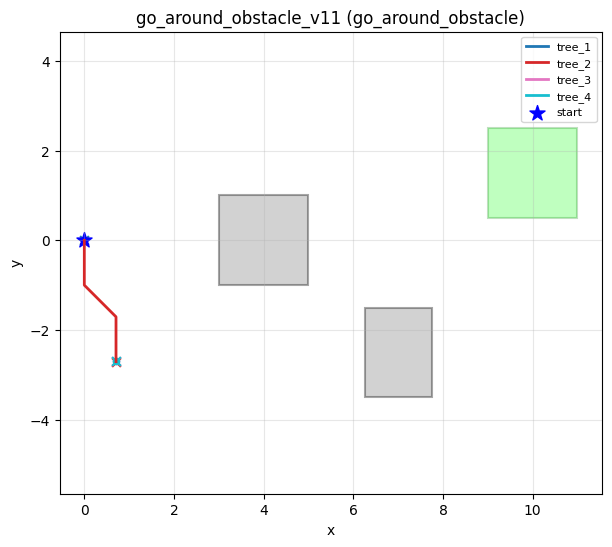


=== task_id: go_around_obstacle_v12 ===


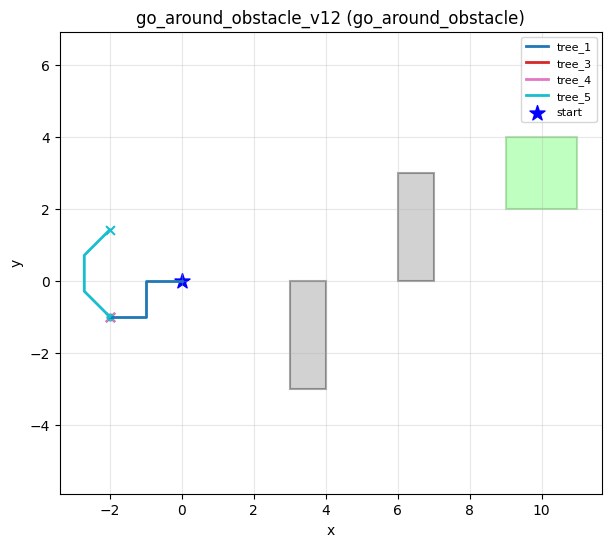


=== task_id: go_around_obstacle_v13 ===


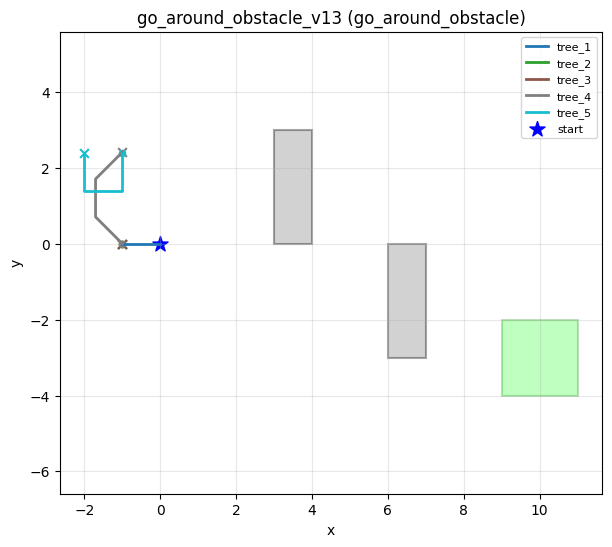


=== task_id: go_around_obstacle_v14 ===


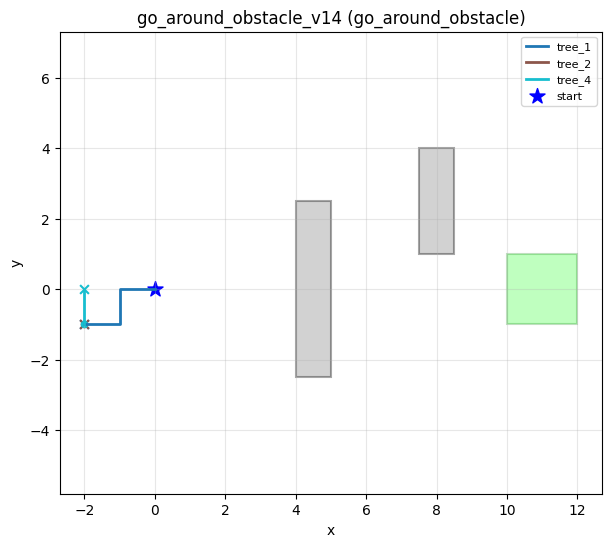


=== task_id: go_around_obstacle_v15 ===


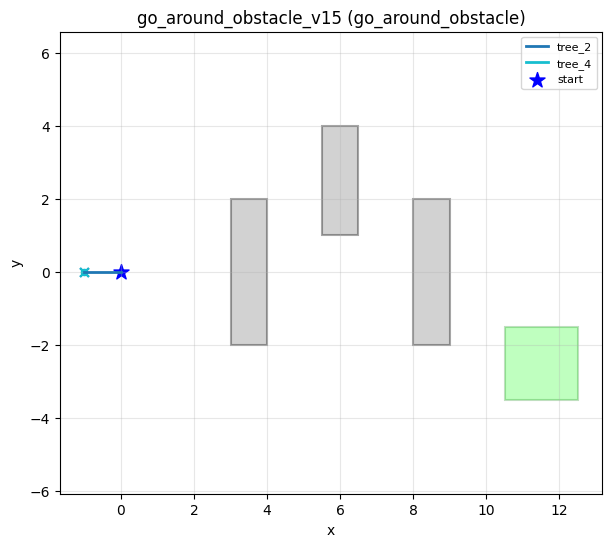


=== task_id: go_around_obstacle_v16 ===


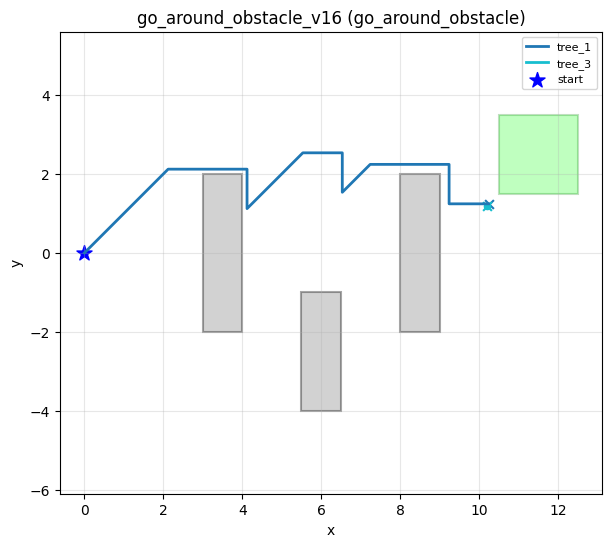


=== task_id: go_around_obstacle_v17 ===


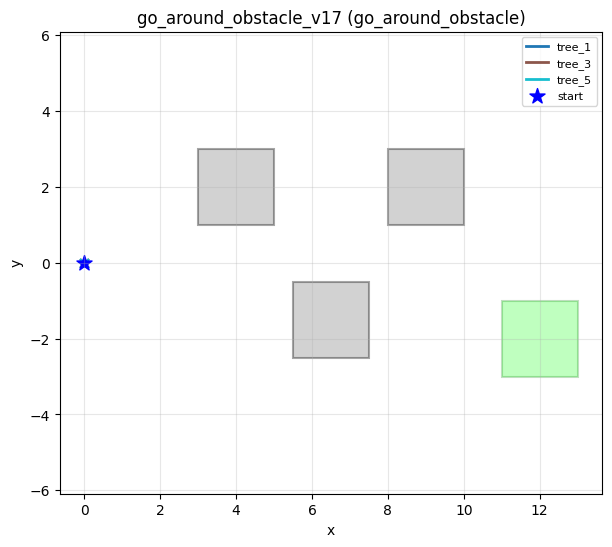


=== task_id: go_around_obstacle_v18 ===


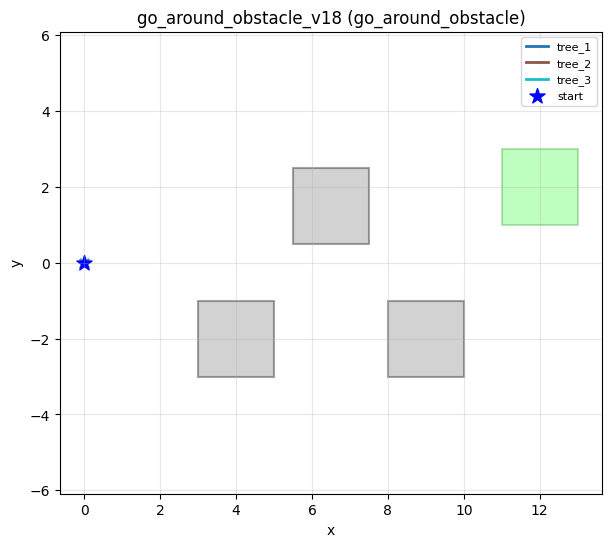


=== task_id: go_around_obstacle_v19 ===


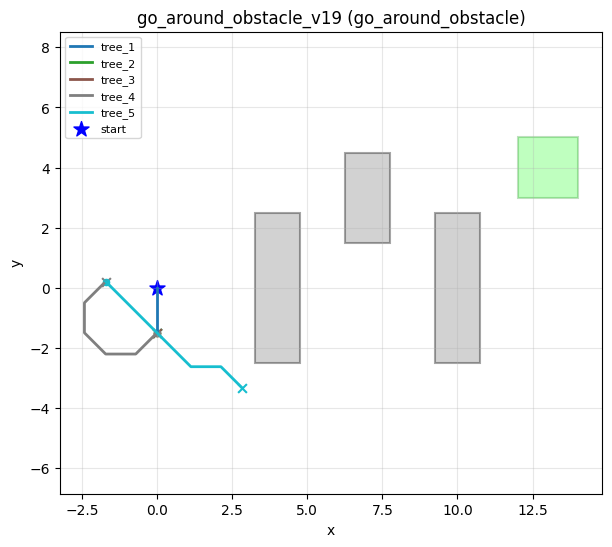


=== task_id: go_around_obstacle_v20 ===


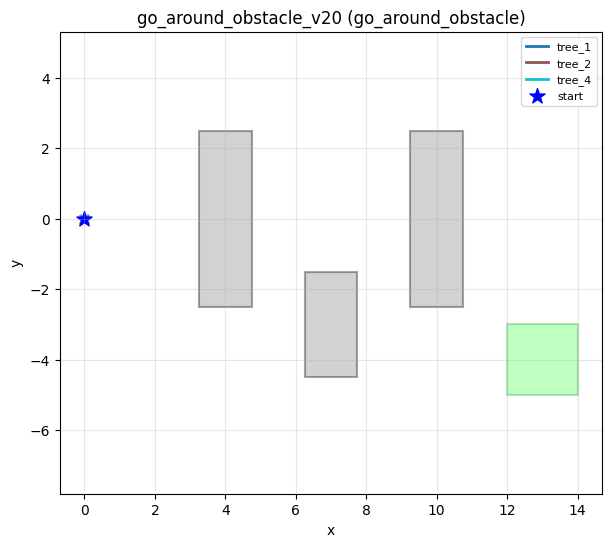


go_around_obstacle: plotted=20, skipped_no_parsed=0


In [15]:
plot_maps_for_task_type("go_around_obstacle", 1, 20)